# <u>**Machine Learning Practices - Project (CS2008p)**</u>


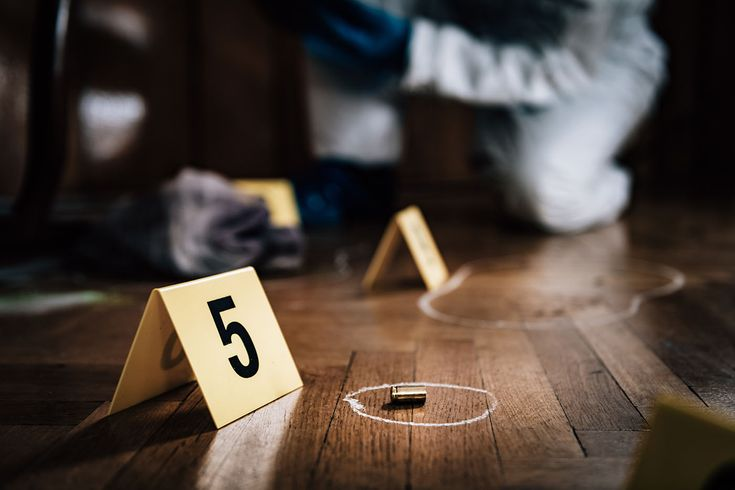

## <u>**Project Details** :-</u>
### This is my MLP Project and the problem statement given to us is comprehensive snapshot of criminal activities within the city, Our task is to  develop models capable of accurately predicting the crime categories based on the information and data provided


## <u>**About me:-**</u>

| Info          | Description  |
|--------------|-----------------|
| NAME         | AYUSHI DIXIT  | 
| ROLL NO    | 22F3000082    | 
| E-MAIL       |  22F3000082@ds.study.iitm.ac.in  | 
|COURSE    |  Machine Learning Practices    | 



# Basic Framework to work on the Project 
 ### 1. Define the Problem
 ### 2. Gather the Data
###  3. Prepare Data to work on it 
 ### 4. Perform Exploratory Analysis with Statistics
 ### 5. Model Data
 ### 6. Validate and Implement
 ### 7. Optimize and Submission
 

---------------------------------------------------------------------------------------------------------------------------------------------


# Step 1 - Define the Problem
## CrimeCast: Forecasting Crime Categories
A dataset filled with information about crime incidents. We'll look at where the incidents happened, details about the victims including    date, time, location, victim demographics, and more. and analyze other important factors and work on the data and use this data to predict the type of crime that occurred.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crime-cast-forecasting-crime-categories/sample.csv
/kaggle/input/crime-cast-forecasting-crime-categories/train.csv
/kaggle/input/crime-cast-forecasting-crime-categories/test.csv


---------------------------------------------------------------------------------------------------------------------------------------------



# <u>Step 2 - Gather the Data</u>
### The dataset **CrimeCast: Forecasting Crime Categories** is provided to us by our couse team. 
## The dataset consists of the following files:
###  train.csv: The training set, inclusive of the target variable ```crime_category``` and relevant feature attributes.<n>
###  test.csv: The test set,on which prediction are to be performned

---------------------------------------------------------------------------------------------------------------------------------------------


# Step 3 - Prepare Data to work on it

### Importing Libraries

In [2]:
import numpy as np
print("NumPy version: {}". format(np.__version__))
import pandas as pd
print("pandas version: {}". format(pd.__version__))
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.tools import FigureFactory as ff
from plotly.offline import init_notebook_mode,iplot



NumPy version: 1.26.4
pandas version: 2.2.2


### Read Data

In [3]:
df = train = pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/train.csv")
test = pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/test.csv")

### Shape of the data
Let’s have a look at data dimensionality, feature names, and feature types.

In [4]:
print(df.shape, test.shape)

(20000, 22) (5000, 21)


**Dataset(train) contains 22 columns and 20,000 rows <br>
Test dataset contains 21 columns and 5000 rows**

 ### Printing first 4 rows and last 4 rows of the Dataset to get the gist of what data has to offer

In [5]:
df.head(4)


,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description,Crime_Category
0,4500 CARPENTER AV,NaN,34.1522,-118.3910,03/09/2020 12:00:00 AM,03/06/2020 12:00:00 AM,1800.0,15.0,N Hollywood,1563.0,...,75.0,M,W,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
1,45TH ST,ALAMEDA ST,34.0028,-118.2391,02/27/2020 12:00:00 AM,02/27/2020 12:00:00 AM,1345.0,13.0,Newton,1367.0,...,41.0,M,H,216.0,SWAP MEET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes
2,600 E MARTIN LUTHER KING JR BL,NaN,34.0111,-118.2653,08/21/2020 12:00:00 AM,08/21/2020 12:00:00 AM,605.0,13.0,Newton,1343.0,...,67.0,M,B,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,Property Crimes
3,14900 ORO GRANDE ST,NaN,34.2953,-118.4590,11/08/2020 12:00:00 AM,11/06/2020 12:00:00 AM,1800.0,19.0,Mission,1924.0,...,61.0,M,H,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes


---------------------------------------------------------------------------------------------------------------------------------------------

# <u>Step 4 - Perform Exploratory Analysis with Statistics</u>

### Now let's try printing out column names using columns:

In [6]:
df.columns

Index(['Location', 'Cross_Street', 'Latitude', 'Longitude', 'Date_Reported',
       'Date_Occurred', 'Time_Occurred', 'Area_ID', 'Area_Name',
       'Reporting_District_no', 'Part 1-2', 'Modus_Operandi', 'Victim_Age',
       'Victim_Sex', 'Victim_Descent', 'Premise_Code', 'Premise_Description',
       'Weapon_Used_Code', 'Weapon_Description', 'Status',
       'Status_Description', 'Crime_Category'],
      dtype='object')

### The complete dataset has 22 columns where the variable types are:

| Variable      | Count  |
|--------------|-----------------|
| TEXT         | 5  | 
| NUMERIC    | 8    | 
| DATETIME       |  2  | 
|CATEGORICAL    |  7  | 


## <u>Column Summary</u>

### Knowing about the datatypes of each attribute, nullvalues present and their respective value count <n>
```column_summary``` function used here will generate a summary of the columns in a DataFrame(df). This summary includes various statistics and insights about each column, such as the data type, the number of missing values, the number of unique values, and the distribution of the most frequent values

In [7]:
def column_summary(df):
    summary_data = [] #An empty list summary_data is created to store the summary information for each column.
    
    # Iterating Over Columns
    for col_name in df.columns:
        col_dtype = df[col_name].dtype #Stores the data type 
        num_of_nulls = df[col_name].isnull().sum() #Calculates the number of missing (null) values
        num_of_non_nulls = df[col_name].notnull().sum() #Calculates the number of non-null (not missing) values
        num_of_distinct_values = df[col_name].nunique() #Counts the number of unique values 

        if num_of_distinct_values <= 10:
            distinct_values_counts = df[col_name].value_counts().to_dict() #count of each distinct value in the column 
        else:
            top_10_values_counts = df[col_name].value_counts().head(10).to_dict()  #retrieves the counts for the top 10 most frequent values in the column
            distinct_values_counts = {k: v for k, v in sorted(top_10_values_counts.items(), key=lambda item: item[1], reverse=True)} #sorted in descending order

            # A dictionary is added to the summary_data list.
        summary_data.append({ 
            'col_name': col_name,
            'col_dtype': col_dtype,
            'num_of_nulls': num_of_nulls,
            'num_of_non_nulls': num_of_non_nulls,
            'num_of_distinct_values': num_of_distinct_values,
            'distinct_values_counts': distinct_values_counts
        })

    summary_df = pd.DataFrame(summary_data) #summary_data list is converted into a DataFrame(summary_df)
    return summary_df

summary_df = column_summary(df)
display(summary_df)

,col_name,col_dtype,num_of_nulls,num_of_non_nulls,num_of_distinct_values,distinct_values_counts
0,Location,object,0,20000,12399,"{'6TH': 33, '7TH': 32, 'VERMONT ..."
1,Cross_Street,object,16552,3448,1495,"{'BROADWAY': 56, 'FIGUEROA': 43, 'VERMONT ..."
2,Latitude,float64,0,20000,3622,"{34.2012: 90, 34.1867: 86, 34.1016: 86, 34.098..."
3,Longitude,float64,0,20000,3578,"{-118.2739: 168, -118.2827: 139, -118.2915: 88..."
4,Date_Reported,object,0,20000,811,"{'07/13/2020 12:00:00 AM': 87, '06/16/2020 12:..."
5,Date_Occurred,object,0,20000,366,"{'01/01/2020 12:00:00 AM': 137, '03/01/2020 12..."
6,Time_Occurred,float64,0,20000,996,"{1200.0: 850, 1700.0: 576, 1800.0: 569, 2000.0..."
7,Area_ID,float64,0,20000,21,"{12.0: 1345, 14.0: 1157, 1.0: 1156, 3.0: 1130,..."
8,Area_Name,object,0,20000,21,"{'77th Street': 1345, 'Pacific': 1157, 'Centra..."
9,Reporting_District_no,float64,0,20000,1120,"{645.0: 99, 162.0: 85, 1494.0: 74, 1822.0: 72,..."


**float64 and object are the data types of our features. 13 features are of type object, and 9 features are float64. With this same method, we can easily see there are missing values. Here, there are a few columns which contribute to missing elements in the dataset.**

### <u>The valuable insights from the data are:</u>
* **Cross_Street has 16552 (82.8%) missing values**
* **Modus_Operandi has 2741 (13.7%) missing values**
* **Victim_Sex has 2624 (13.1%) missing values** 
* **Victim_Descent has 2624 (13.1%) missing values**
* **Weapon_Used_Code has 12665 (63.3%) missing values**
* **Weapon_Description has 12665 (63.3%) missing values** 


## <u>General Statistics of Data</u>

**The ```df.describe``` method shows basic statistical characteristics of each numerical feature (float64 types): number of non-missing values, mean, standard deviation, range, median, 0.25 and 0.75 quartiles.**

In [8]:
#knowing about the basic statistics of the data 
df.describe()

,Latitude,Longitude,Time_Occurred,Area_ID,Reporting_District_no,Part 1-2,Victim_Age,Premise_Code,Weapon_Used_Code
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,7335.000000
mean,33.940704,-117.893072,1352.380350,10.834250,1129.599200,1.418150,30.135000,297.176950,366.405044
std,2.126810,7.377726,646.100291,6.033166,603.330519,0.493267,21.863645,212.007298,120.485687
min,0.000000,-118.663400,1.000000,1.000000,101.000000,1.000000,-2.000000,101.000000,101.000000
25%,34.009200,-118.429700,930.000000,6.000000,632.000000,1.000000,12.000000,101.000000,312.000000
50%,34.058700,-118.323000,1430.000000,11.000000,1162.000000,1.000000,31.000000,203.000000,400.000000
75%,34.165025,-118.274400,1900.000000,16.000000,1622.000000,2.000000,46.000000,501.000000,400.000000
max,34.328100,0.000000,2359.000000,21.000000,2197.000000,2.000000,99.000000,969.000000,515.000000


**To see statistics on non-numerical features, we will indicate the data types of column in the ```include``` parameter..**

In [9]:
df.describe(include=["object"])

,Location,Cross_Street,Date_Reported,Date_Occurred,Area_Name,Modus_Operandi,Victim_Sex,Victim_Descent,Premise_Description,Weapon_Description,Status,Status_Description,Crime_Category
count,20000,3448,20000,20000,20000,17259,17376,17376,19995,7335,20000,20000,20000
unique,12399,1495,811,366,21,10489,4,17,216,57,5,5,6
top,6TH,BROADWAY,07/13/2020 12:00:00 AM,01/01/2020 12:00:00 AM,77th Street,0344,M,H,STREET,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes
freq,33,56,87,137,1345,826,8538,6143,5033,3990,15236,15236,11666


**For categorical feature(Victim_Sex) we can use the ```value_counts``` method.**

In [10]:
df["Victim_Sex"].value_counts()

Victim_Sex
M    8538
F    7176
X    1660
H       2
Name: count, dtype: int64

**The distribution of ```Victim_Sex``` <n>
    8538 victims out of 20000 are male and 7176 are female. <br>
    To calculate fractions, pass ```normalize=True``` to the value_counts function.**

In [11]:
#pass normalize=True to the value_counts function to get fractions
df["Victim_Sex"].value_counts(normalize=True)

Victim_Sex
M    0.491367
F    0.412983
X    0.095534
H    0.000115
Name: proportion, dtype: float64

**counting the number of cases that belong to each part1-2**

In [12]:
df['Part 1-2'].value_counts()

Part 1-2
1.0    11637
2.0     8363
Name: count, dtype: int64

In [13]:
print(df.duplicated().sum())

13


**The Duplicate Rows Present in the dataset are: 13**

In [14]:
print('The percentage of missing cells in the data are:',round(df.isna().sum().sum() / df.size * 100, 1),'%')

The percentage of missing cells in the data are: 11.3 %


**In complete dataset there are 11.3% of the cells which have missing values**

## <u>Data Transformation</u>


In [15]:
#gathering the categorical columns together
req_col = df.drop(columns=['Location', 'Cross_Street', 'Date_Reported', 'Date_Occurred', 'Area_Name', 'Victim_Sex', 'Victim_Descent', 'Premise_Description', 'Weapon_Description', 'Status', 'Status_Description', 'Crime_Category', 'Modus_Operandi' ])

### Label Encoding: Convert categorical labels into numeric format.

In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['Crime_Category'])
le1 = LabelEncoder()
req_col['Status'] = le1.fit_transform(df['Status'])
le2 = LabelEncoder()
req_col['Victim_Descent'] = le2.fit_transform(df['Victim_Descent'])
le3 = LabelEncoder()
req_col['Victim_Sex'] = le3.fit_transform(df['Victim_Sex'])
req_col["Crime_Category"] = y

**The Statistics of the data shows that there are negative values present in the ```Victim_Age``` column of the dataset** <br>
**There are total of 6 rows which have age in negative**<br>
**Imputing missing ages with the median age**

In [17]:
# number of columns with negative age
negative_age_df = df[df['Victim_Age'] < 0]

# Display rows with negative Victim_Age values
negative_age_df

age = df['Victim_Age'].median()
df["Victim_Age"]= df['Victim_Age'].fillna(age)


### To know distribution of crime incidents happening throughout the day

In [18]:
def check_time(time):
  # Assumimg Sunrise at 6am i.e. 600 hrs and Sunset at 8pm i.e. 2000hrs
  if time >= 0 and time < 600:
    return 'Midnight to 6 AM'
  elif time >= 600 and time < 1200:
    return '6 AM to 12 noon'
  elif time >= 1200  and time < 1800:
    return '12 noon to 1800 hrs'
  elif time >= 1800:
    return 'After 1800 hrs'


In [19]:
(df['Time_Occurred'].apply(check_time)).value_counts()

Time_Occurred
12 noon to 1800 hrs    6683
After 1800 hrs         6362
6 AM to 12 noon        3994
Midnight to 6 AM       2961
Name: count, dtype: int64

### Insights:
 **<u>Peak Hours:</u> The afternoon and evening periods (from 12 noon to 1800 hrs and after 1800 hrs) see the highest number of crimes, i.e. higher crime activity during these times**. <br>
 **<u>Off-Peak Hours:</u> The early morning hours (midnight to 6 AM) have the lowest number of crime incidents, indicating lower activity.**

## <u>Visual Data Representation</u>

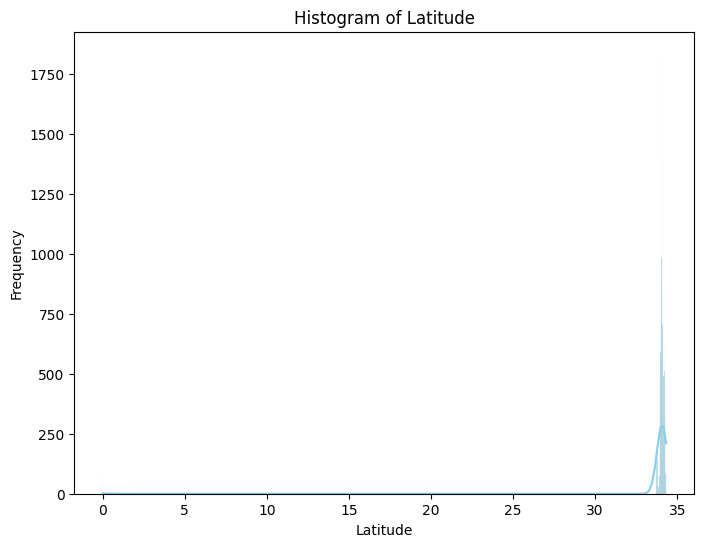

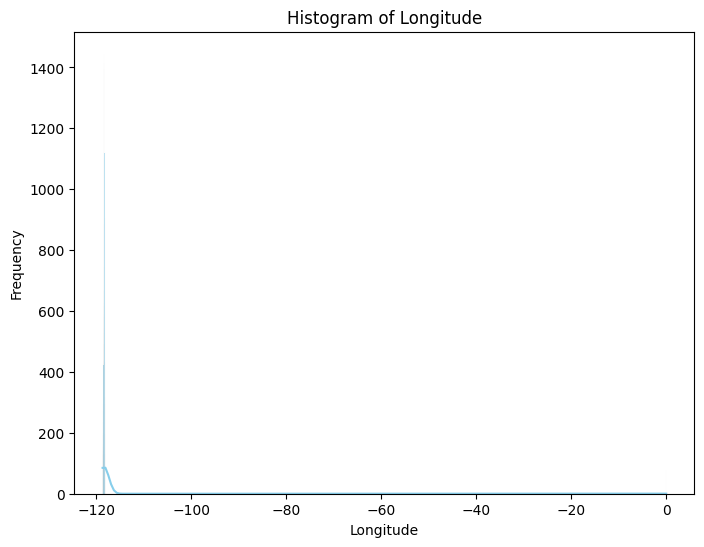

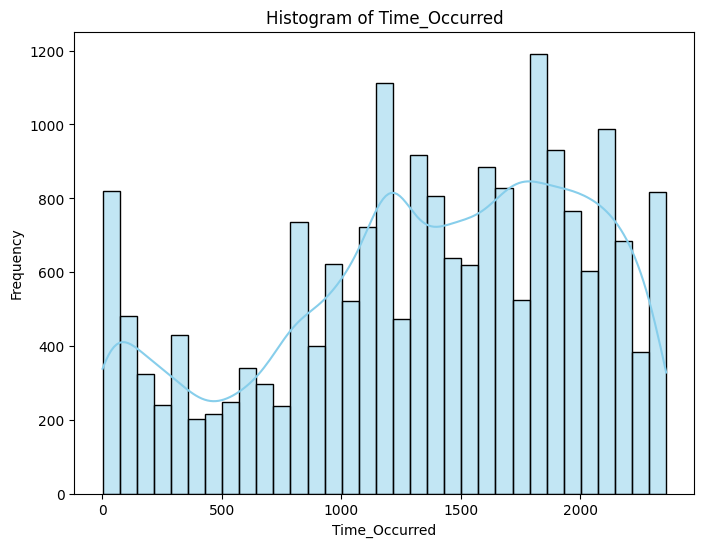

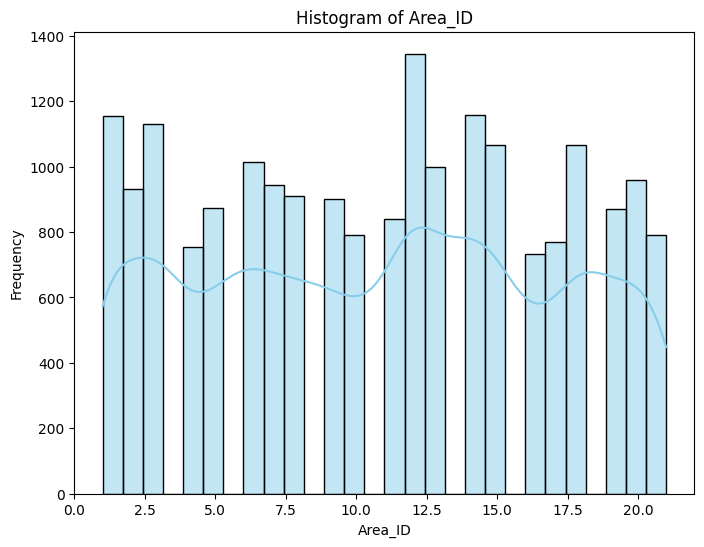

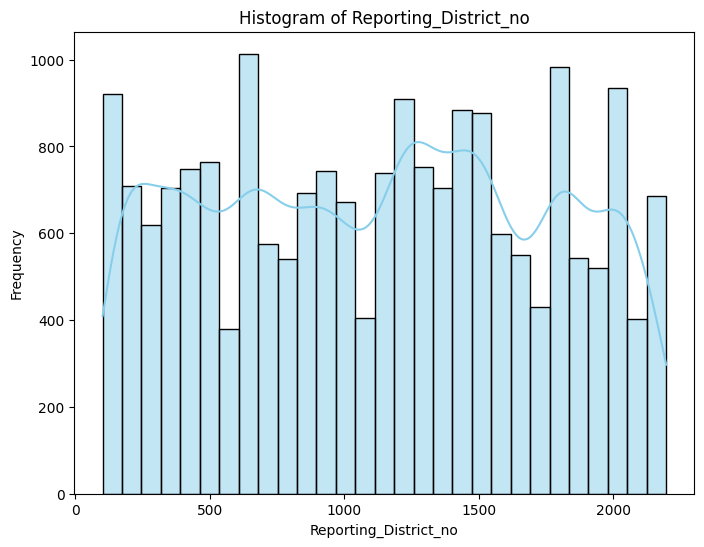

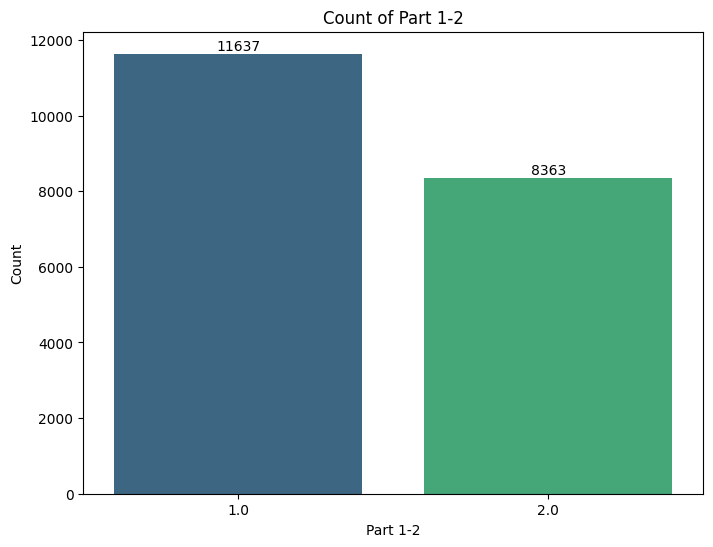

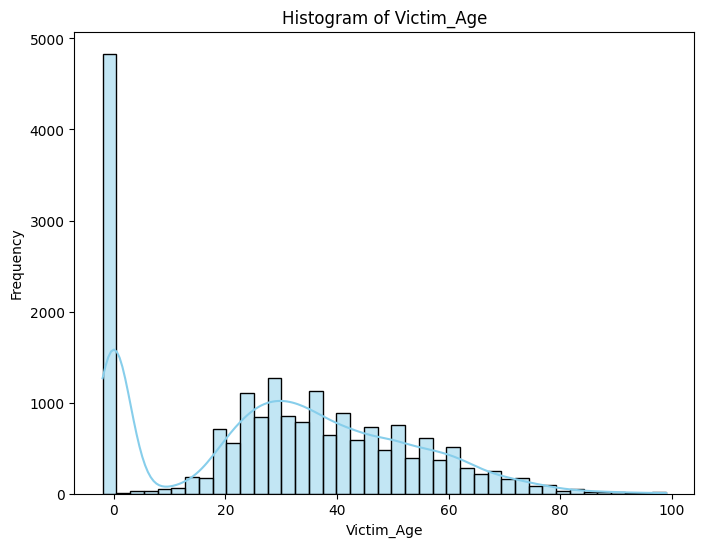

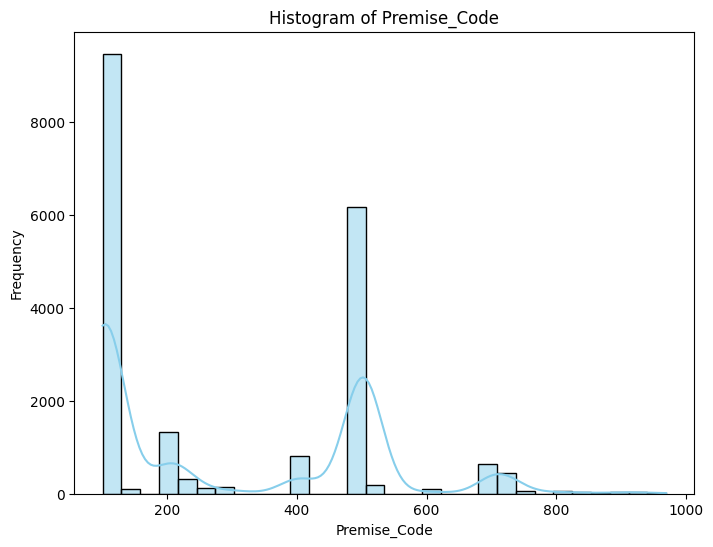

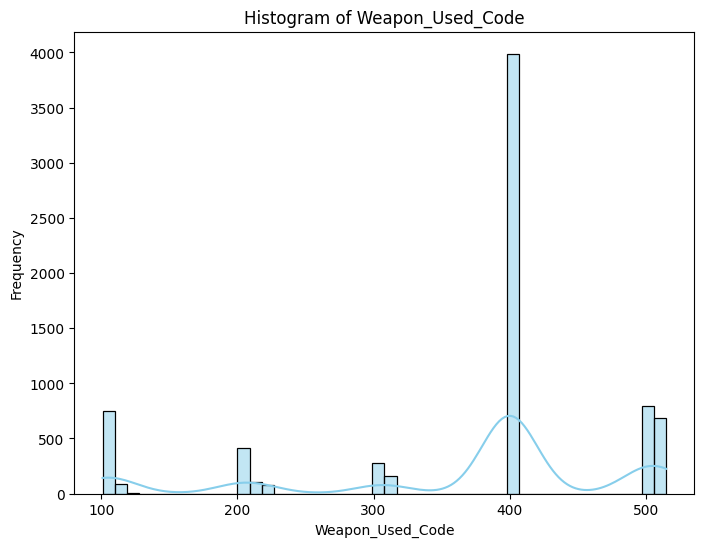

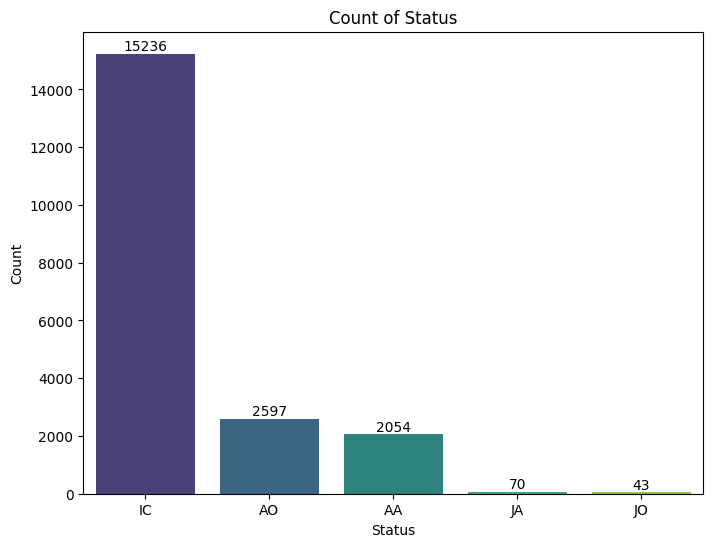

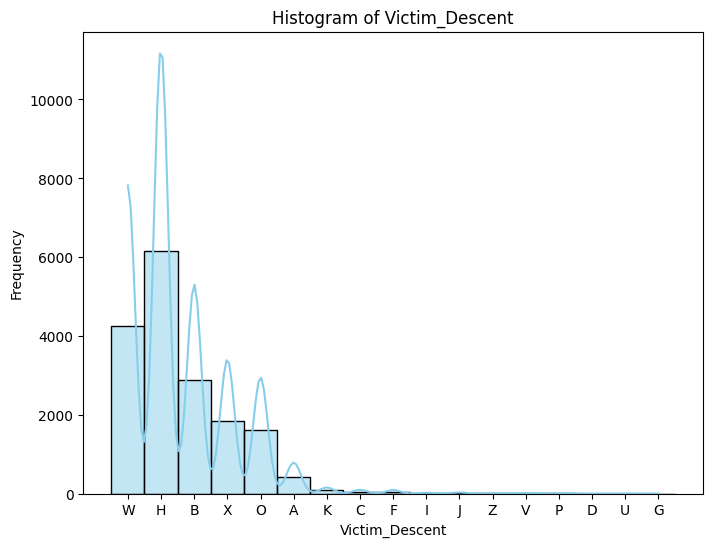

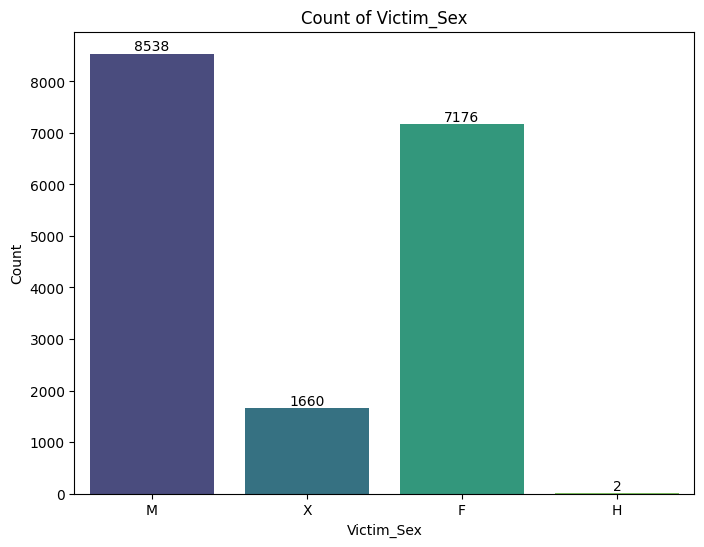

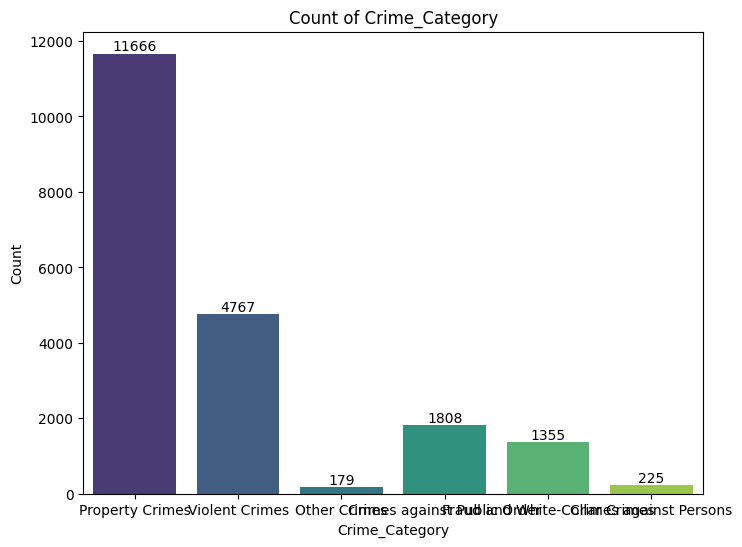

In [20]:
import warnings
import pandas as pd

# Suppress the FutureWarning
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    with pd.option_context('mode.use_inf_as_na', True):
        
        numerical_columns = req_col
        for column in numerical_columns:
            # For continuous variables
            if len(df[column].unique()) > 10:  # Assuming if unique values > 10, consider it continuous
                plt.figure(figsize=(8, 6))
                sns.histplot(df[column], kde=True ,color='skyblue')
                plt.title(f'Histogram of {column}')
                plt.xlabel(column)
                plt.ylabel('Frequency')
                plt.show()
            else:  # For discrete or ordinal variables
                plt.figure(figsize=(8, 6))
                ax = sns.countplot(x=column, data=df , palette='viridis')
                plt.title(f'Count of {column}')
                plt.xlabel(column)
                plt.ylabel('Count')
        
        # Annotate each bar with its count
                for p in ax.patches:
                    ax.annotate(format(p.get_height(), '.0f'), 
                                (p.get_x() + p.get_width() / 2., p.get_height()), 
                                ha = 'center', va = 'center', 
                                xytext = (0, 5), 
                                textcoords = 'offset points')
                plt.show()

**For each column in numerical_columns with more than 10 unique values, it generates a histogram with a Kernel Density Estimate (KDE)** <br> 
where *Kernel Density Estimation (KDE)* is a statistical technique used to estimate the probability density function of a continuous random variable. It provides a smoothed curve that represents the distribution of data points.<br>
**For each column with 10 or fewer unique values, it generates a count plot, and annotates each bar with its respective count value.**

---------------------------------------------------------------------------------------------------------------------------------------------


### **Plotly library  ```plotly.express``` module is used to create a map visualization** <br>
**The map will display data points based on their geographic coordinates (latitude and longitude) and color-code them according to a categorical feature(Crime_Category) which represent different categories of crimes.**

In [21]:
import plotly.express as px
warnings.filterwarnings("ignore", message="When grouping with a length-1 list-like", category=FutureWarning)
fig = px.scatter_mapbox(df, 
                        lat="Latitude", 
                        lon="Longitude", 
                        hover_name="Location", 
                        hover_data=["Location", "Area_ID"],
                        color='Crime_Category',
                        zoom=8, 
                        height=700,
                        width=1300)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

In [22]:
df.Crime_Category.value_counts() 

Crime_Category
Property Crimes                  11666
Violent Crimes                    4767
Crimes against Public Order       1808
Fraud and White-Collar Crimes     1355
Crimes against Persons             225
Other Crimes                       179
Name: count, dtype: int64

---------------------------------------------------------------------------------------------------------------------------------------------

### **Seaborn's ```pairplot``` function creates a grid of plots showing pairwise relationships in the dataset. Each numeric column in req_col is plotted against every other numeric column.**

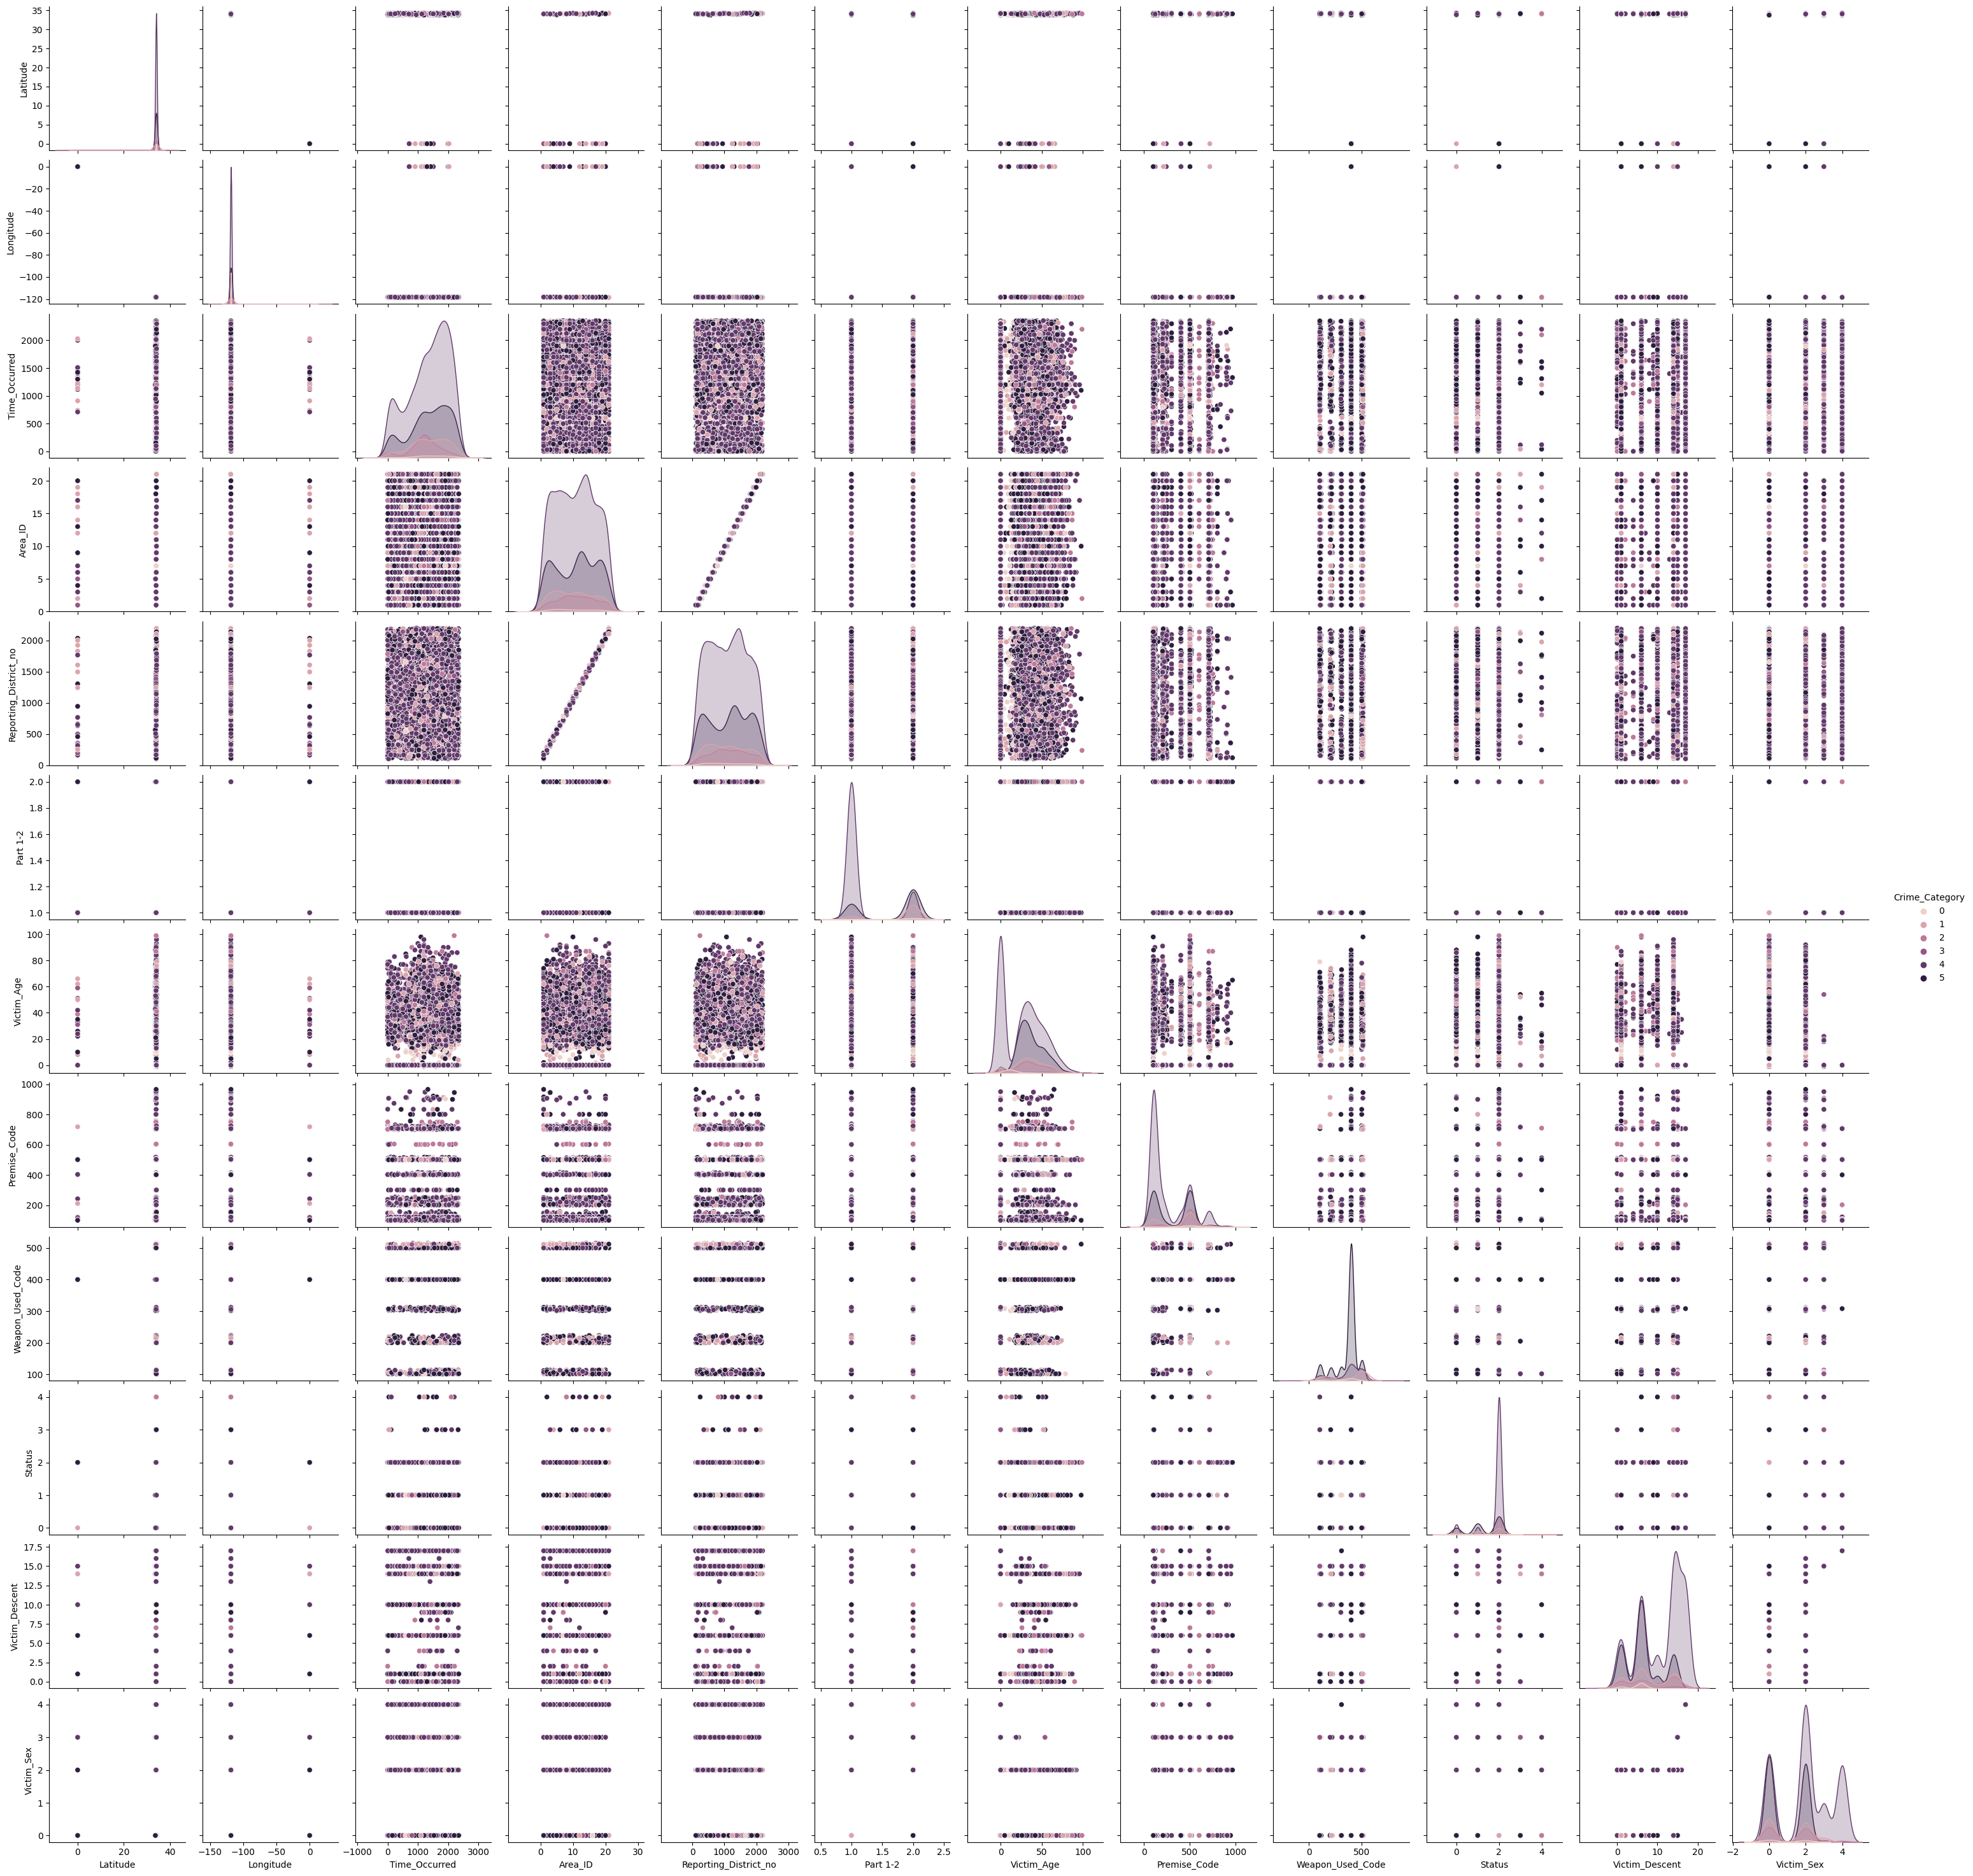

In [23]:
#from plotly.tools import FigureFactory as ff
#from plotly.offline import init_notebook_mode,iplot
import seaborn as sns

# Suppress the FutureWarnings
warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated", category=FutureWarning)
warnings.filterwarnings("ignore", message="When grouping with a length-1 list-like", category=FutureWarning)
sns.pairplot(req_col.sample(int(20000/4)), diag_kind='kde', hue='Crime_Category', dropna=True)
plt.show()

**Visualizing the pairwise relationships between columns in a dataset using Seaborn's pairplot, which helps us in understanding correlations and distributions among the columns. The plot includes KDE plots on the diagonal and color points based on a categorical variable (Crime_Category).**

---------------------------------------------------------------------------------------------------------------------------------------------

### **Creating a heatmap that visualizes the correlation matrix of a DataFrame(req_col).**

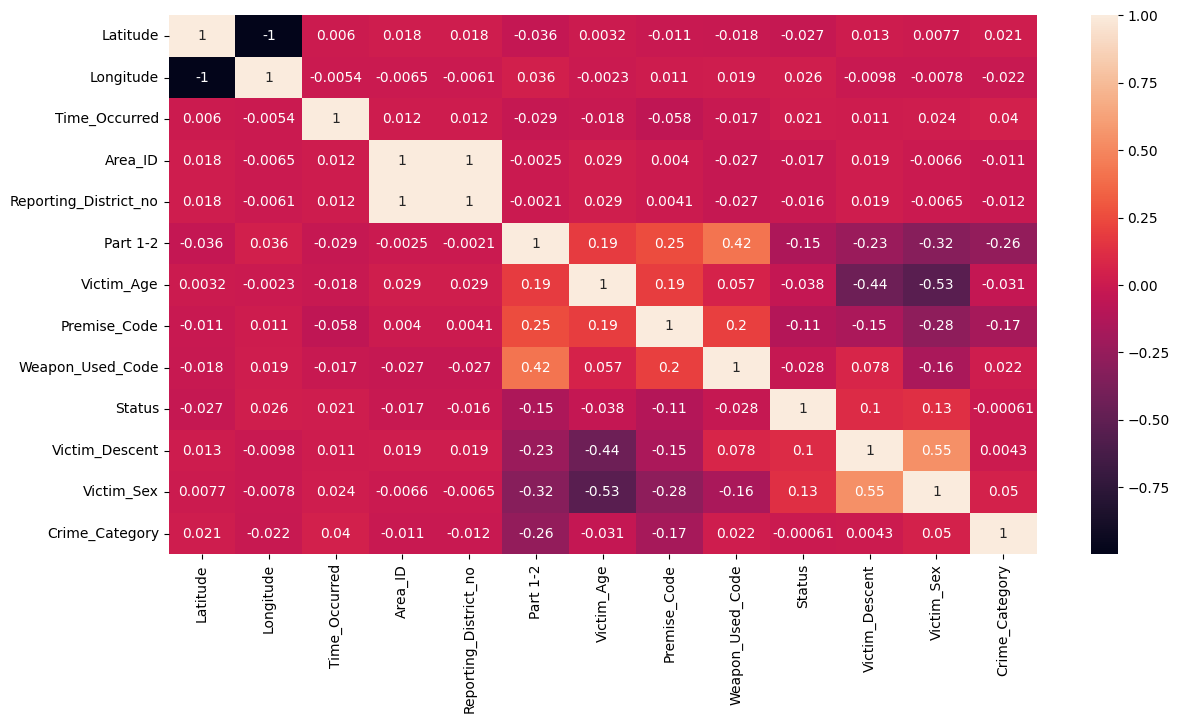

In [24]:
#importing the libraries
import seaborn as sn
import matplotlib.pyplot as plt
plt.figure(figsize=(14,7))
corrd = req_col.corr() #Calculating the Correlation Matrix
hm = sn.heatmap(corrd, annot=True) #Creating the Heatmap
plt.show()

### This computes the correlation matrix for the dataset and creates a heatmap to visualize the correlations between different features.
* The heatmap suggests that variables like ``` "Part 1-2", "Victim Age", "Premise Code", "Weapon Used Code", "Status", "Victim Descent", "Victim Sex",``` and``` "Crime Category" ``` are important features 
* The correlation between ```["Latitude"] and ["Longitude"]``` is perfectly negative**(-1)**. This indicates that as the latitude increases, the longitude decreases.
* The correlation between ```["Area_ID"] and ["Reporting_District_no"]``` is perfectly positive**(1)**, these two variables are likely identical or have a direct linear relationship which means they could be redundant.
* A correlation of **-0.44** between ```["Victim_Descent"] and ["Victim_Age"]``` indicates that certain victim descents might correlate with specific age groups negatively.
* ```["Victim_Sex']and ["Victim_Age']``` have a correlation of **-0.53** suggests a strong negative relationship, indicating that certain age groups are predominantly of one sex.
* ```(["Victim_Sex'] and ["Victim_Descent"])``` and ```(["Part 1-2"] and ["Weapon_Used_Code"])``` have a moderate positive relationship. 

## 5 point summary

* **Now we will plot graphs which tell us about 5 point summary, This loop iterates over all the columns in the req_col, applying the ```five_point_summary``` function to each. A five-point summary will be calculated, printed, and the corresponding box/boxen plot will be displayed.**
* **The box plot visually represents this summary, helping to identify outliers, the spread, and the skewness of the data.**



        *****************************************************
        			***************
        			5 Point Summary
        			***************
        Attribute: Latitude
        Minimum value: 0.0
        First Quartile value: 34.0092
        Second Quartile(Median) value: 34.0587
        Third Quartile value: 34.165025
        Maximum value: 34.3281
        *****************************************************
        			**************
        			Box/Boxen Plot
        			**************
        


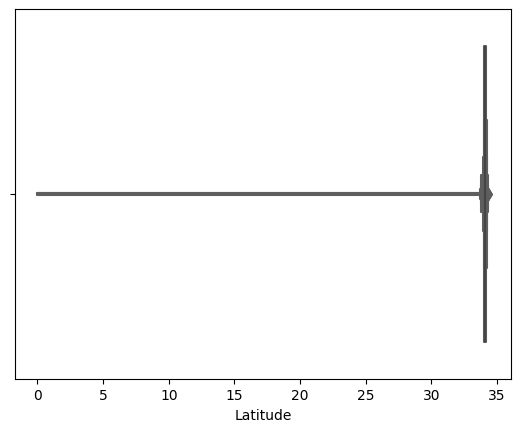


        *****************************************************
        			***************
        			5 Point Summary
        			***************
        Attribute: Longitude
        Minimum value: -118.6634
        First Quartile value: -118.4297
        Second Quartile(Median) value: -118.323
        Third Quartile value: -118.2744
        Maximum value: 0.0
        *****************************************************
        			**************
        			Box/Boxen Plot
        			**************
        


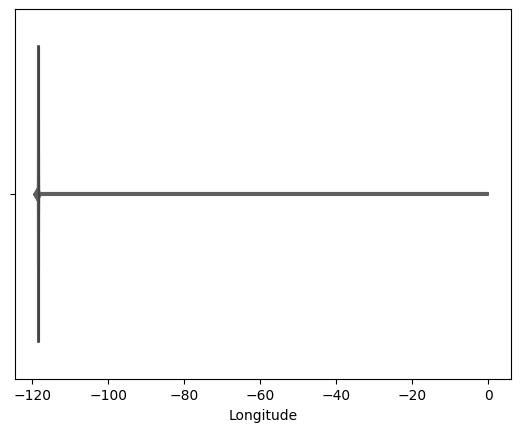


        *****************************************************
        			***************
        			5 Point Summary
        			***************
        Attribute: Time_Occurred
        Minimum value: 1.0
        First Quartile value: 930.0
        Second Quartile(Median) value: 1430.0
        Third Quartile value: 1900.0
        Maximum value: 2359.0
        *****************************************************
        			**************
        			Box/Boxen Plot
        			**************
        


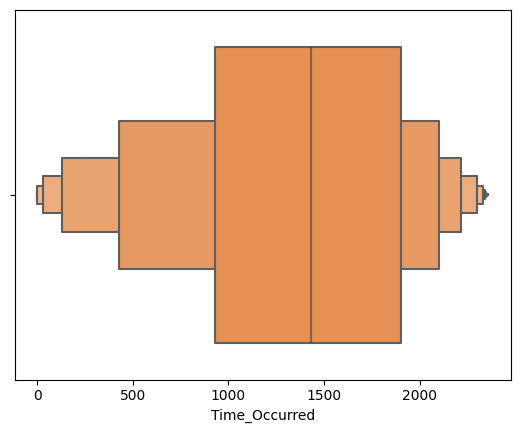


        *****************************************************
        			***************
        			5 Point Summary
        			***************
        Attribute: Area_ID
        Minimum value: 1.0
        First Quartile value: 6.0
        Second Quartile(Median) value: 11.0
        Third Quartile value: 16.0
        Maximum value: 21.0
        *****************************************************
        			**************
        			Box/Boxen Plot
        			**************
        


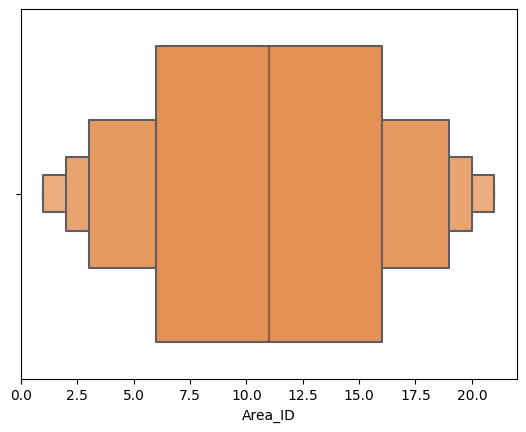


        *****************************************************
        			***************
        			5 Point Summary
        			***************
        Attribute: Reporting_District_no
        Minimum value: 101.0
        First Quartile value: 632.0
        Second Quartile(Median) value: 1162.0
        Third Quartile value: 1622.0
        Maximum value: 2197.0
        *****************************************************
        			**************
        			Box/Boxen Plot
        			**************
        


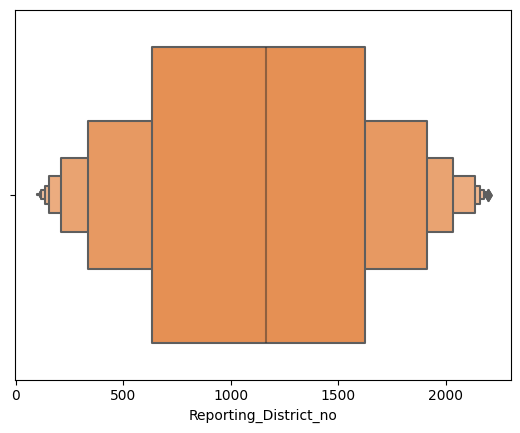


        *****************************************************
        			***************
        			5 Point Summary
        			***************
        Attribute: Part 1-2
        Minimum value: 1.0
        First Quartile value: 1.0
        Second Quartile(Median) value: 1.0
        Third Quartile value: 2.0
        Maximum value: 2.0
        *****************************************************
        			**************
        			Box/Boxen Plot
        			**************
        


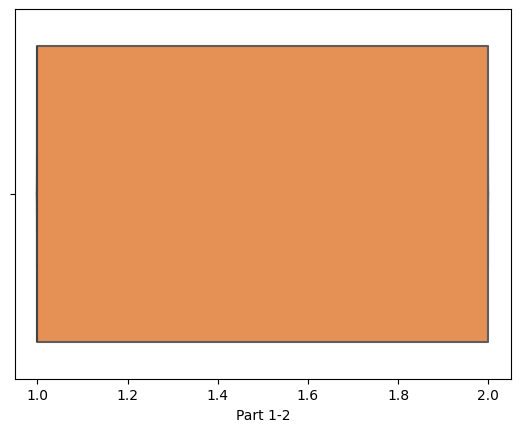


        *****************************************************
        			***************
        			5 Point Summary
        			***************
        Attribute: Victim_Age
        Minimum value: -2.0
        First Quartile value: 12.0
        Second Quartile(Median) value: 31.0
        Third Quartile value: 46.0
        Maximum value: 99.0
        *****************************************************
        			**************
        			Box/Boxen Plot
        			**************
        


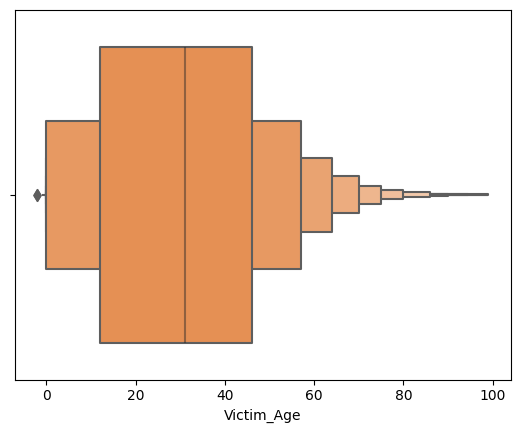


        *****************************************************
        			***************
        			5 Point Summary
        			***************
        Attribute: Premise_Code
        Minimum value: 101.0
        First Quartile value: 101.0
        Second Quartile(Median) value: 203.0
        Third Quartile value: 501.0
        Maximum value: 969.0
        *****************************************************
        			**************
        			Box/Boxen Plot
        			**************
        


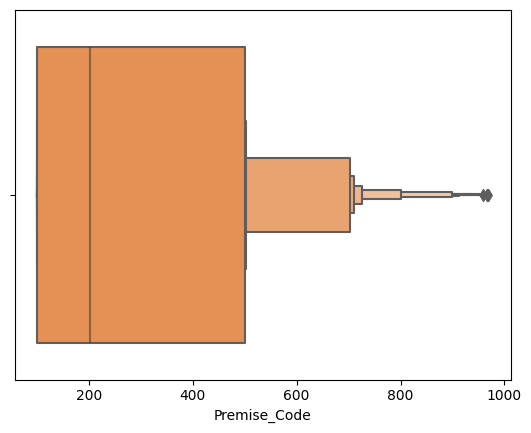


        *****************************************************
        			***************
        			5 Point Summary
        			***************
        Attribute: Weapon_Used_Code
        Minimum value: 101.0
        First Quartile value: 312.0
        Second Quartile(Median) value: 400.0
        Third Quartile value: 400.0
        Maximum value: 515.0
        *****************************************************
        			**************
        			Box/Boxen Plot
        			**************
        


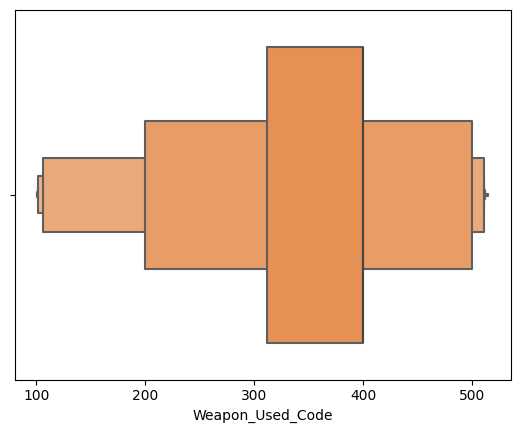


        *****************************************************
        			***************
        			5 Point Summary
        			***************
        Attribute: Status
        Minimum value: 0
        First Quartile value: 2.0
        Second Quartile(Median) value: 2.0
        Third Quartile value: 2.0
        Maximum value: 4
        *****************************************************
        			**************
        			Box/Boxen Plot
        			**************
        


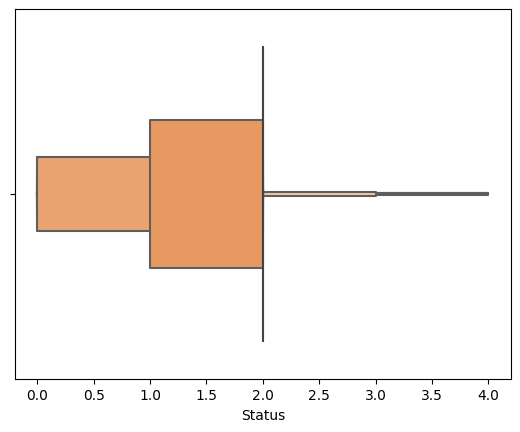


        *****************************************************
        			***************
        			5 Point Summary
        			***************
        Attribute: Victim_Descent
        Minimum value: 0
        First Quartile value: 6.0
        Second Quartile(Median) value: 10.0
        Third Quartile value: 14.0
        Maximum value: 17
        *****************************************************
        			**************
        			Box/Boxen Plot
        			**************
        


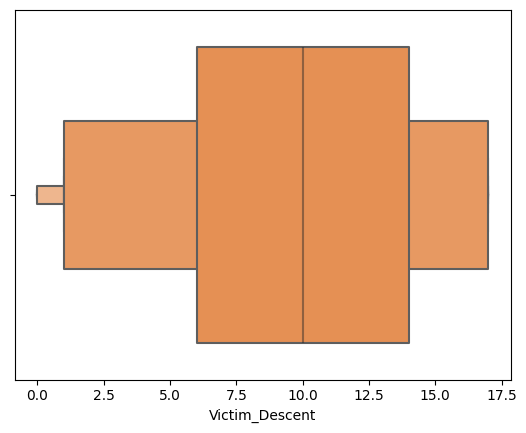


        *****************************************************
        			***************
        			5 Point Summary
        			***************
        Attribute: Victim_Sex
        Minimum value: 0
        First Quartile value: 0.0
        Second Quartile(Median) value: 2.0
        Third Quartile value: 2.0
        Maximum value: 4
        *****************************************************
        			**************
        			Box/Boxen Plot
        			**************
        


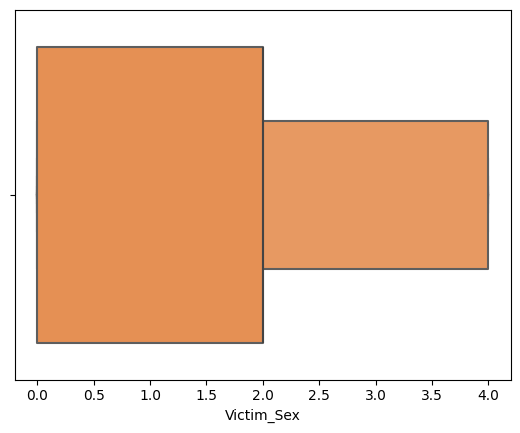


        *****************************************************
        			***************
        			5 Point Summary
        			***************
        Attribute: Crime_Category
        Minimum value: 0
        First Quartile value: 4.0
        Second Quartile(Median) value: 4.0
        Third Quartile value: 4.0
        Maximum value: 5
        *****************************************************
        			**************
        			Box/Boxen Plot
        			**************
        


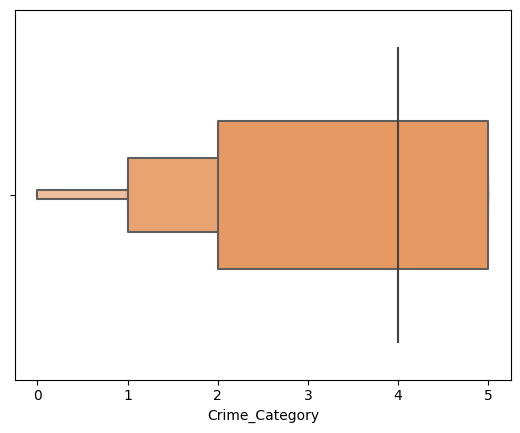

In [25]:
#defining the function
def five_point_summary(X_train, attribute_name):
    if attribute_name in X_train.columns: #checks if attribute_name exists 
        #Calculating the Five-Point Summary
        data_min = X_train[attribute_name].min()
        data_q1 = X_train[attribute_name].quantile(0.25)
        data_q2 = X_train[attribute_name].quantile(0.5)
        data_q3 = X_train[attribute_name].quantile(0.75)
        data_max = X_train[attribute_name].max()
        #Printing the Summary
        output= f"""
        *****************************************************
        \t\t\t***************
        \t\t\t5 Point Summary
        \t\t\t***************
        Attribute: {attribute_name}
        Minimum value: {data_min}
        First Quartile value: {data_q1}
        Second Quartile(Median) value: {data_q2}
        Third Quartile value: {data_q3}
        Maximum value: {data_max}
        *****************************************************
        \t\t\t**************
        \t\t\tBox/Boxen Plot
        \t\t\t**************
        """
        print(output)
        #Plotting the Box/Boxen Plot
        sns.boxenplot(x=attribute_name, palette='YlOrRd', data=X_train)
        #the plot is displayed
        return plt.show()
    else:
        return print("Attribute name doesn't exist in the given data")
    
#Applying the Function to All Attributes
for attribute_name in req_col:
    five_point_summary(req_col, attribute_name)

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# <u>Step 5 - PREPROCESSING</u>

### Importing other Libraries

In [26]:
from sklearn.metrics import accuracy_score,confusion_matrix , f1_score
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier,RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegressionCV
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.pipeline import make_pipeline , Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer , CountVectorizer
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer

**Handling missing values in specific columns of the DataFrame (df) by replacing them with appropriate default values.** <br>
**This process aims to clean the data by ensuring that missing values are replaced with appropriate default values**

In [27]:
df = train 
df['Weapon_Description'] = df['Weapon_Description'].fillna('')

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
# Defining the specific columns for imputation
string_columns = ['Cross_Street', 'Modus_Operandi', 'Victim_Sex', 'Victim_Descent', 'Weapon_Description']
numeric_columns = ['Weapon_Used_Code']

# Creating a pipeline for imputing string columns
string_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=''))
])

# Creating a pipeline for imputing numeric columns
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])


# Combining the pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('str', string_pipeline, string_columns),
        ('num', numeric_pipeline, numeric_columns)
    ],
    remainder='passthrough'  # To keep the other columns as they are
)

# Applying the ColumnTransformer to the DataFrame
df_imputed = preprocessor.fit_transform(df)

# Convert the result back to a DataFrame with the original column names
# Assuming df.columns gives the original column order
df = df_imputed = pd.DataFrame(df_imputed, columns=df.columns)

In [29]:
df = train
 
df['Cross_Street'] = df['Cross_Street'].fillna('')
df['Modus_Operandi'] = df['Modus_Operandi'].fillna('')
df['Victim_Sex'] = df['Victim_Sex'].fillna('')
df['Victim_Descent'] = df['Victim_Descent'].fillna('')
df['Weapon_Used_Code'] = df['Weapon_Used_Code'].fillna(0)
df['Weapon_Description'] = df['Weapon_Description'].fillna('')

### For text-based columns, missing values are replaced with empty strings, while for the ```Weapon_Used_Code```, a numeric column, missing values are replaced with 0.

In [30]:
y = df['Crime_Category']
X = df.drop('Crime_Category',axis=1)
print(df.shape, y.shape)
print(train.shape)

(20000, 22) (20000,)
(20000, 22)


In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X train shape : ", X_train.shape)
print("X test shape : ", X_test.shape)
print("y train shape : ", y_train.shape)
print("y test shape : ", y_test.shape)

X train shape :  (16000, 21)
X test shape :  (4000, 21)
y train shape :  (16000,)
y test shape :  (4000,)


In [32]:
accscore = []
f1score = []
modelname = []

### Baseline model

**Constructing a Baseline Model**

The DummyClassifier is a baseline classifier used for benchmarking, it doesn't use any actual learning algorithm, it follows a basic rule or strategy, such as always predicting the most frequent class.

In [33]:
from sklearn.dummy import DummyClassifier

#Training the DummyClassifier
model=DummyClassifier().fit(X_train,y_train)
#X_test=pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/test.csv")
y_pred=model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(acc) #Prints the accuracy score

f1 = f1_score(y_test, y_pred, average='weighted')
accscore.append(acc)
f1score.append(f1)
modelname.append('Dummy')

0.57575


### Creating a column transformer for all the data cleaning

**Applying different preprocessing techniques to different types of features (numerical and categorical) using a ColumnTransformer.**

In [34]:
# numerical attributes:
numerical_cols = ['Latitude', 'Longitude', 'Time_Occurred', 'Area_ID', 'Reporting_District_no', 'Part 1-2', 'Victim_Age', 'Premise_Code', 'Weapon_Used_Code']
# Categorical attributes: For categorical encoding
#transformed using different text vectorization techniques.
text_feature1 = 'Location'
text_feature2 = 'Modus_Operandi'
text_feature3 = 'Weapon_Description'

In [35]:
#Transformers
num_trans = StandardScaler()
text_trans = TfidfVectorizer(stop_words='english', max_features=6000) #converts a collection of text documents to a matrix 
text_count = CountVectorizer() #converts a collection of text documents to a matrix of token counts

# Imputes the numerical and categorical attributes
preprocessor = ColumnTransformer(
    transformers=[               #setting up the transformer
        ('num', num_trans, numerical_cols),
        ('Location', text_trans, text_feature1),
        ('Clause_no', text_count, text_feature2),
        ('Weapon_Description', text_trans, text_feature3)
    ])
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Latitude', 'Longitude', 'Time_Occurred',
                                  'Area_ID', 'Reporting_District_no',
                                  'Part 1-2', 'Victim_Age', 'Premise_Code',
                                  'Weapon_Used_Code']),
                                ('Location',
                                 TfidfVectorizer(max_features=6000,
                                                 stop_words='english'),
                                 'Location'),
                                ('Clause_no', CountVectorizer(),
                                 'Modus_Operandi'),
                                ('Weapon_Description',
                                 TfidfVectorizer(max_features=6000,
                                                 stop_words='english'),
                                 'Weapon_Description')])

 ### TF-IDF (Term Frequency-Inverse Document Frequency) and Count Vectorizer are a part of Feature Engineeing 
 * TF-IDF transforms raw text data into numerical features,it also reduces the dimensionality of the text data 

### The above code perform the underwritten tasks:

* **Numerical columns are scaled to have zero mean and unit variance.**
* **Text features are converted to numerical feature vectors using TF-IDF or Count Vectorization.**
* **The resulting transformed features can then be fed into a machine learning model for training.**

# <u>Step 6 - Model Training</u>

### Splitting the Data into Training and Testing Sets

**splits the dataset into training and testing sets, with 80% of the data used for training and 20% reserved for testing.**

In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
yx = le.fit_transform(y)

from sklearn.model_selection import train_test_split
X_trainx, X_testx, y_trainx, y_testx = train_test_split(X, yx, test_size=0.2, random_state=42) 

print("X train shape : ", X_train.shape)
print("X test shape : ", X_test.shape)
print("y train shape : ", y_train.shape)
print("y test shape : ", y_test.shape)

X train shape :  (16000, 21)
X test shape :  (4000, 21)
y train shape :  (16000,)
y test shape :  (4000,)


### Confusion Matrix

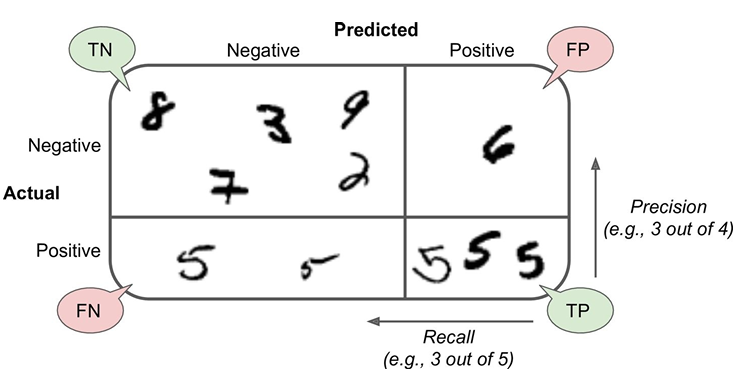

## <u>xgboost</u>

**Implementing a classification model using XGBoost (XGBClassifier) in combination with a pipeline for preprocessing.**

0.95775
              precision    recall  f1-score   support

           0     0.7273    0.7500    0.7385        32
           1     0.8270    0.8690    0.8475       374
           2     0.9570    0.9176    0.9369       267
           3     0.4000    0.1714    0.2400        35
           4     0.9913    0.9909    0.9911      2303
           5     0.9481    0.9596    0.9538       989

    accuracy                         0.9577      4000
   macro avg     0.8084    0.7764    0.7846      4000
weighted avg     0.9557    0.9577    0.9562      4000



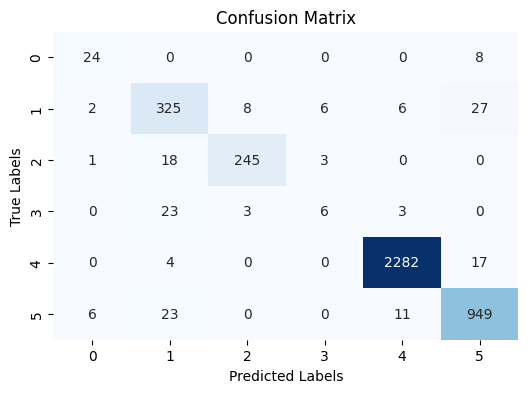

In [37]:
#xgboost

from xgboost import XGBClassifier
xgb = XGBClassifier()
pipexgb = make_pipeline(preprocessor, xgb)
pipexgb.fit(X_trainx, y_trainx)
y_predx = pipexgb.predict(X_testx)
xgb_acc = accuracy_score(y_testx, y_predx)
print(xgb_acc)
print(classification_report(y_testx, y_predx, digits=4))

accscore.append(xgb_acc)
f1score.append(f1)
modelname.append('xgb')


# Generate confusion matrix
cm = confusion_matrix(y_testx, y_predx)
# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=True, yticklabels=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()




* **The code is setting up the pipeline that first preprocesses the data and then trains an XGBoost classifier on it.**
* **The performance of the model is then evaluated using accuracy and a classification report that provides detailed metrics for each class.**
* **Predictions are made on a test dataset, and the model's performance is evaluated using accuracy, a classification report, and a confusion matrix.**

### Hyperparameter Tuning (HPT) for xgboost

In [38]:
'''
# Create the pipeline
pipexgb = make_pipeline(preprocessor, xgb)

# Define the parameter grid
param_grid = {
    'xgbclassifier__n_estimators': [100, 200, 300],
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__subsample': [0.8, 0.9, 1.0],
    'xgbclassifier__colsample_bytree': [0.8, 0.9, 1.0],
    'xgbclassifier__gamma': [0, 0.1, 0.3],
    'xgbclassifier__reg_alpha': [0, 0.01, 0.1],
    'xgbclassifier__reg_lambda': [1, 1.5, 2]
}

# Perform GridSearchCV
grid_search = GridSearchCV(pipexgb, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_trainx, y_trainx)

# Get the best parameters and the best accuracy
best_params = grid_search.best_params()
best_accuracy = grid_search.best_score()

print(f"Best parameters: {best_params}")
'''

'\n# Create the pipeline\npipexgb = make_pipeline(preprocessor, xgb)\n\n# Define the parameter grid\nparam_grid = {\n    \'xgbclassifier__n_estimators\': [100, 200, 300],\n    \'xgbclassifier__learning_rate\': [0.01, 0.05, 0.1],\n    \'xgbclassifier__max_depth\': [3, 5, 7],\n    \'xgbclassifier__subsample\': [0.8, 0.9, 1.0],\n    \'xgbclassifier__colsample_bytree\': [0.8, 0.9, 1.0],\n    \'xgbclassifier__gamma\': [0, 0.1, 0.3],\n    \'xgbclassifier__reg_alpha\': [0, 0.01, 0.1],\n    \'xgbclassifier__reg_lambda\': [1, 1.5, 2]\n}\n\n# Perform GridSearchCV\ngrid_search = GridSearchCV(pipexgb, param_grid, cv=5, scoring=\'accuracy\', n_jobs=-1, verbose=2)\ngrid_search.fit(X_trainx, y_trainx)\n\n# Get the best parameters and the best accuracy\nbest_params = grid_search.best_params()\nbest_accuracy = grid_search.best_score()\n\nprint(f"Best parameters: {best_params}")\n'

---------------------------------------------------------------------------------------------------------------



## <u>K-Nearest Neighbors (KNN) Classifier</u>
* **K-Nearest Neighbors (KNN) is a simple, classification algorithm which operates based on the principle that similar data points are likely to be close to each other in the feature space.** <br>
* **```k``` is number of neighbors to consider for classification<br>**
* **KNN calculates the distance between the new point and all the points in the training dataset**.



KNN Classifier accuracy: 0.91625
Accuracy: 0.91625
Classification Report:
                               precision    recall  f1-score   support

       Crimes against Persons       0.38      0.19      0.25        32
  Crimes against Public Order       0.76      0.75      0.76       374
Fraud and White-Collar Crimes       0.85      0.89      0.87       267
                 Other Crimes       0.17      0.03      0.05        35
              Property Crimes       0.95      0.98      0.96      2303
               Violent Crimes       0.93      0.89      0.91       989

                     accuracy                           0.92      4000
                    macro avg       0.67      0.62      0.63      4000
                 weighted avg       0.91      0.92      0.91      4000

F1 Score: 0.9111781523224664


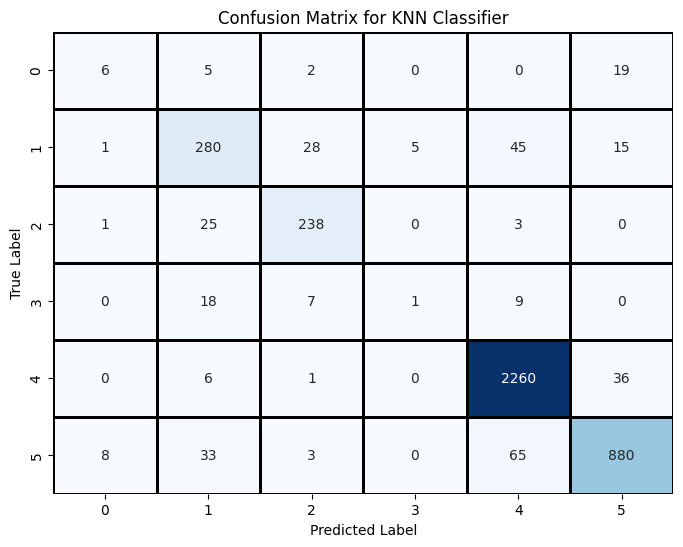

In [39]:
# Create a KNN classifier
knn_classifier = KNeighborsClassifier()
# Create a pipeline with preprocessing and the KNN classifier
pipelineknn = make_pipeline(preprocessor, knn_classifier)
# Train the pipeline on the training data
pipelineknn.fit(X_train, y_train)
# Predict the target values for the test data
y_pred = pipelineknn.predict(X_test)
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
# Print the accuracy of the KNN classifier
print(f'KNN Classifier accuracy: {accuracy}')

#getting the F1 score

f1 = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)
print(f'F1 Score: {f1}')

accscore.append(accuracy)
f1score.append(f1)
modelname.append('KNN')

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for KNN Classifier')
plt.show()

* **Setting up KNN classifier, preprocesses the data, trains the model, and evaluates its performance.**
* **Calculates the F1 score, which is the harmonic mean of precision and recall. It’s useful when you need a balance between precision and recall.**
* **```average='weighted'``` calculates the F1 score for each class and averages them.**


In [40]:
pipelineknn

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Latitude', 'Longitude',
                                                   'Time_Occurred', 'Area_ID',
                                                   'Reporting_District_no',
                                                   'Part 1-2', 'Victim_Age',
                                                   'Premise_Code',
                                                   'Weapon_Used_Code']),
                                                 ('Location',
                                                  TfidfVectorizer(max_features=6000,
                                                                  stop_words='english'),
                                                  'Location'),
                                                 ('Clause_no',
                                                  CountVectorizer(),
                                                  'Modus_Operandi'),
                                                 ('Weapon_Description',
                                                  TfidfVectorizer(max_features=6000,
                                                                  stop_words='english'),
                                                  'Weapon_Description')])),
                ('kneighborsclassifier', KNeighborsClassifier())])

## Support Vector Machine

/opt/conda/lib/python3.10/site-packages/sklearn/svm/_base.py:299: ConvergenceWarning:

Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.



SVM Classifier accuracy: 0.9575
Accuracy: 0.9575
Classification Report:
                               precision    recall  f1-score   support

       Crimes against Persons       0.59      0.50      0.54        32
  Crimes against Public Order       0.84      0.87      0.86       374
Fraud and White-Collar Crimes       0.94      0.94      0.94       267
                 Other Crimes       0.75      0.34      0.47        35
              Property Crimes       0.99      0.99      0.99      2303
               Violent Crimes       0.95      0.96      0.95       989

                     accuracy                           0.96      4000
                    macro avg       0.84      0.77      0.79      4000
                 weighted avg       0.96      0.96      0.96      4000

F1 Score: 0.9562706377987792


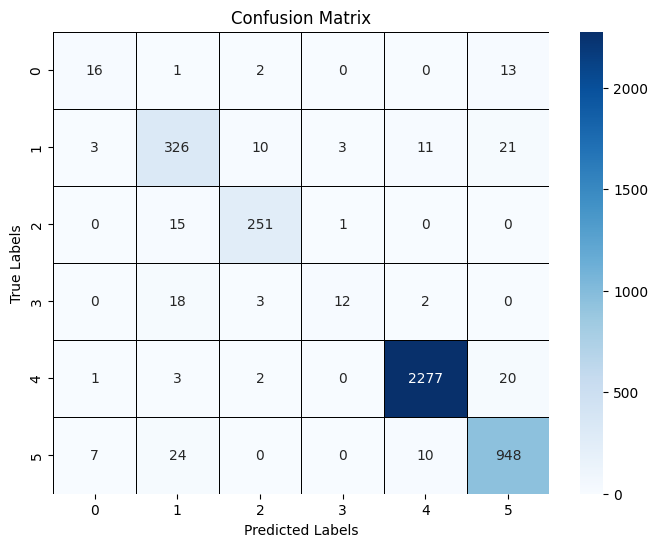

In [41]:
# Create an SVM classifier
svm_classifier = SVC(C=9, kernel="rbf", gamma=0.025, shrinking=True, probability=True, tol=1e-3, 
                     class_weight=None, max_iter=2000, decision_function_shape="ovo")
# Create a pipeline with preprocessing and the SVM classifier
pipelinesvm = make_pipeline(preprocessor, svm_classifier)
# Train the pipeline on the training data
pipelinesvm.fit(X_train, y_train)
# Predict the target values for the test data
y_pred = pipelinesvm.predict(X_test)
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
# Print the accuracy of the SVM classifier
print(f'SVM Classifier accuracy: {accuracy}')

f1 = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)
print(f'F1 Score: {f1}')

accscore.append(accuracy)
f1score.append(f1)
modelname.append('SVM')


# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix with border and color
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, linewidths=0.5, linecolor='black',
            xticklabels=True, yticklabels=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [42]:
#HPT
'''
param_grid = {
    'svc__C': [1, 5, 10, 15, 20, 25, 30],
    'svc__gamma': [0.01, 0.05, 0.1, 0.15, 0.2, 0.25],
    'svc__kernel': ['rbf', 'poly', 'sigmoid'],
    'svc__degree': [2, 3, 4],  # for poly kernel
    'svc__coef0': [0.0, 0.1, 0.5, 1.0]  # for poly and sigmoid kernels
}
grid_search = GridSearchCV(pipelinesvm, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_}")
'''

'\nparam_grid = {\n    \'svc__C\': [1, 5, 10, 15, 20, 25, 30],\n    \'svc__gamma\': [0.01, 0.05, 0.1, 0.15, 0.2, 0.25],\n    \'svc__kernel\': [\'rbf\', \'poly\', \'sigmoid\'],\n    \'svc__degree\': [2, 3, 4],  # for poly kernel\n    \'svc__coef0\': [0.0, 0.1, 0.5, 1.0]  # for poly and sigmoid kernels\n}\ngrid_search = GridSearchCV(pipelinesvm, param_grid, cv=5, n_jobs=-1, verbose=2)\ngrid_search.fit(X_train, y_train)\n\nprint(f"Best parameters: {grid_search.best_params_}")\nprint(f"Best cross-validation accuracy: {grid_search.best_score_}")\n'

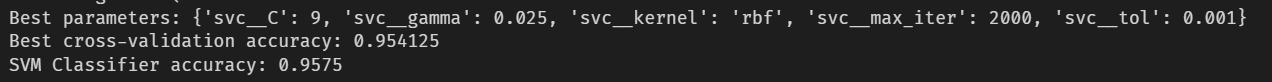

## <u>Decision Tree classifier</u>

Decision Tree Classifier accuracy: 0.9385
Accuracy: 0.9385
Classification Report:
                               precision    recall  f1-score   support

       Crimes against Persons       0.48      0.47      0.48        32
  Crimes against Public Order       0.81      0.76      0.78       374
Fraud and White-Collar Crimes       0.88      0.93      0.90       267
                 Other Crimes       0.40      0.34      0.37        35
              Property Crimes       0.99      0.98      0.99      2303
               Violent Crimes       0.92      0.95      0.93       989

                     accuracy                           0.94      4000
                    macro avg       0.75      0.74      0.74      4000
                 weighted avg       0.94      0.94      0.94      4000

F1 Score: 0.9379414981421237


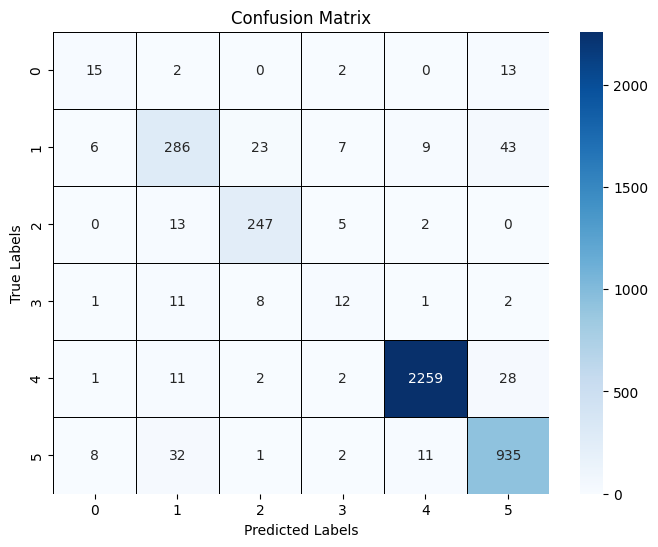

In [43]:
# Create a Decision Tree classifier with maximum depth of 1
dt_classifier = DecisionTreeClassifier(max_depth=17, random_state=45)
# Create a pipeline with preprocessing and the Decision Tree classifier
pipelinedtc = make_pipeline(preprocessor, dt_classifier)
# Train the pipeline on the training data
pipelinedtc.fit(X_train, y_train)
# Predict the target values for the test data
y_pred = pipelinedtc.predict(X_test)
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
# Print the accuracy of the Decision Tree classifier
print(f'Decision Tree Classifier accuracy: {accuracy}')

f1 = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)
print(f'F1 Score: {f1}')

accscore.append(accuracy)
f1score.append(f1)
modelname.append('DecisionTC')

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix with color and borders
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='black')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [44]:
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier,BaggingClassifier,AdaBoostClassifier,VotingClassifier

## <u>AdaBoost classifier</u>

AdaBoost Classifier accuracy: 0.93875
Accuracy: 0.93875
Classification Report:
                               precision    recall  f1-score   support

       Crimes against Persons       0.53      0.50      0.52        32
  Crimes against Public Order       0.82      0.79      0.80       374
Fraud and White-Collar Crimes       0.92      0.90      0.91       267
                 Other Crimes       0.29      0.34      0.31        35
              Property Crimes       0.98      0.98      0.98      2303
               Violent Crimes       0.92      0.94      0.93       989

                     accuracy                           0.94      4000
                    macro avg       0.74      0.74      0.74      4000
                 weighted avg       0.94      0.94      0.94      4000

F1 Score: 0.9389304852011252


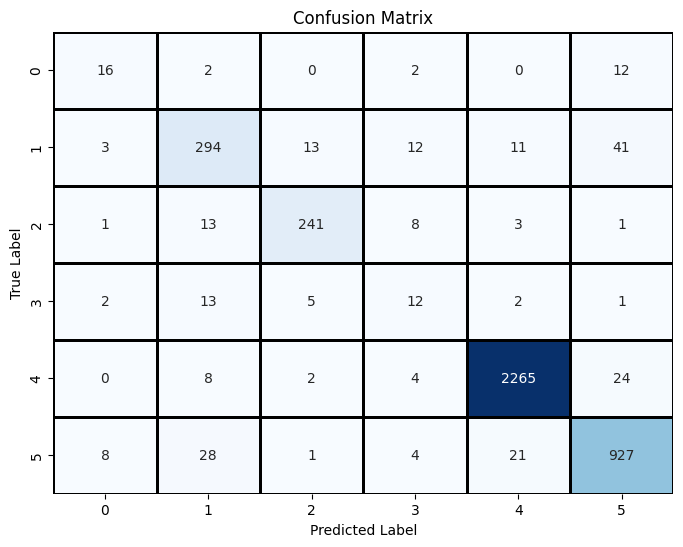

In [45]:
# Defining the base estimator for AdaBoost classifier with max depth 1
base_estimator = DecisionTreeClassifier(max_depth=20)
# Creating an AdaBoost classifier with 100 estimators, learning rate 0.001, and random state 42
adaboost_classifier = AdaBoostClassifier(base_estimator, n_estimators=100, random_state=42, learning_rate=0.001)
# Creating a pipeline with preprocessing and the AdaBoost classifier
pipelineada = make_pipeline(preprocessor, adaboost_classifier)
# Training the pipeline on the training data
pipelineada.fit(X_train, y_train)
# Predicting the target values for the test data
y_pred = pipelineada.predict(X_test)
# Calculating the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
# Printing the accuracy of the AdaBoost classifier
print(f'AdaBoost Classifier accuracy: {accuracy}')

f1 = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)
print(f'F1 Score: {f1}')

accscore.append(accuracy)
f1score.append(f1)
modelname.append('AdaBoost')

#Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# Create a figure and a set of subplots
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show() ## Show the plot

## <u>MLPClassifier (Multi Layer Perceptron)</u>

MLP Classifier accuracy: 0.9485
Accuracy: 0.9485
Classification Report:
                               precision    recall  f1-score   support

       Crimes against Persons       0.68      0.41      0.51        32
  Crimes against Public Order       0.82      0.84      0.83       374
Fraud and White-Collar Crimes       0.95      0.91      0.93       267
                 Other Crimes       0.56      0.26      0.35        35
              Property Crimes       0.98      0.99      0.98      2303
               Violent Crimes       0.93      0.95      0.94       989

                     accuracy                           0.95      4000
                    macro avg       0.82      0.73      0.76      4000
                 weighted avg       0.95      0.95      0.95      4000

F1 Score: 0.9465378603934029


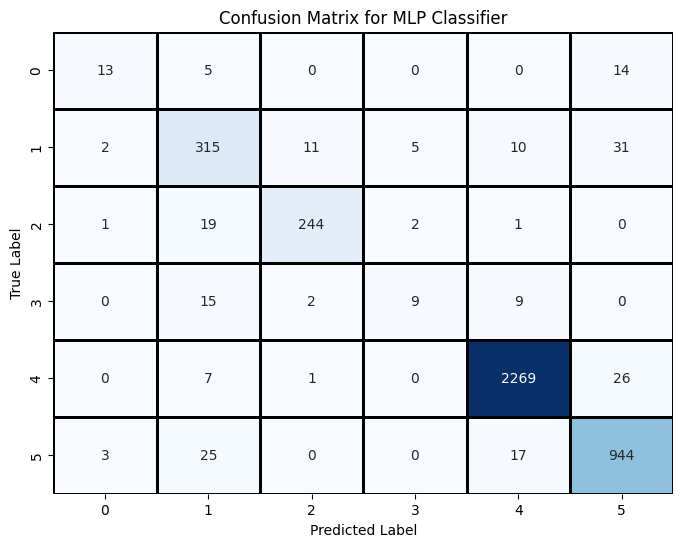

In [46]:
# Creating an MLPClassifier with 1 hidden layer of 100 neurons, 'relu' activation function, 'adam' solver,
# early stopping enabled, maximum iterations set to 1000, and random state 42
mlp_classifier = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', early_stopping=True, max_iter=1000, random_state=42)
# Creating a pipeline with preprocessing and the MLPClassifier
pipelinemlp = make_pipeline(preprocessor, mlp_classifier)
# Training the pipeline on the training data
pipelinemlp.fit(X_train, y_train)
# Predicting the target values for the test data
y_pred = pipelinemlp.predict(X_test)
# Calculating the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
# Printing the accuracy of the MLP Classifier
print(f'MLP Classifier accuracy: {accuracy}')

f1 = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)
print(f'F1 Score: {f1}')

accscore.append(accuracy)
f1score.append(f1)
modelname.append('MLP')

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

# Create a heatmap with a border and color
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for MLP Classifier')
plt.show()

## <u>Random Forest Classifier</u>

Random Forest Classifier accuracy: 0.94225
Accuracy: 0.94225
Classification Report:
                               precision    recall  f1-score   support

       Crimes against Persons       0.38      0.09      0.15        32
  Crimes against Public Order       0.85      0.81      0.83       374
Fraud and White-Collar Crimes       0.94      0.91      0.92       267
                 Other Crimes       0.67      0.06      0.11        35
              Property Crimes       0.98      0.98      0.98      2303
               Violent Crimes       0.90      0.97      0.94       989

                     accuracy                           0.94      4000
                    macro avg       0.78      0.64      0.65      4000
                 weighted avg       0.94      0.94      0.94      4000

F1 Score: 0.9362773268855624


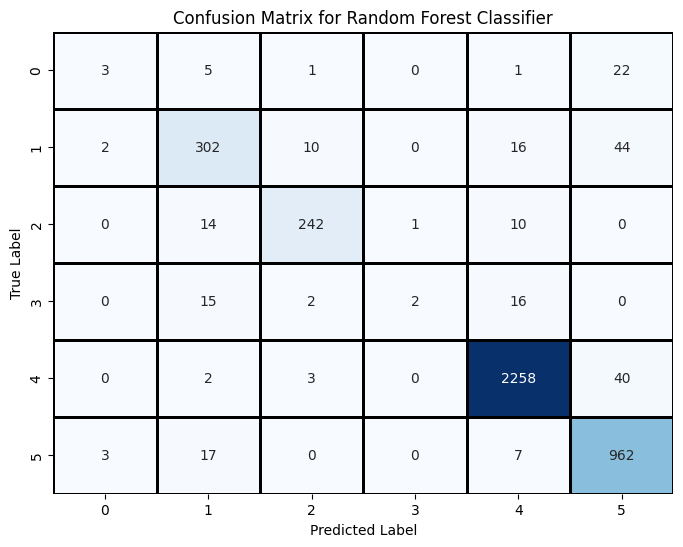

In [47]:
# Defining the Random Forest Classifier with 1000 estimators and random state 42
rf_classifier = RandomForestClassifier(n_estimators=1000, random_state=42)
# Creating a pipeline with preprocessing and the Random Forest Classifier
pipelinerf = make_pipeline(preprocessor, rf_classifier)
# Training the pipeline on the training data
pipelinerf.fit(X_train, y_train)
# Predicting the target values for the test data
y_pred = pipelinerf.predict(X_test)
# Calculating the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
# Printing the accuracy of the Random Forest Classifier
print(f'Random Forest Classifier accuracy: {accuracy}')

f1 = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)
print(f'F1 Score: {f1}')

accscore.append(accuracy)
f1score.append(f1)
modelname.append('RandomFClf')

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black', cbar=False)

# Set the labels and title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()

## <u>lightGBM</u>

LightGBM (Light Gradient Boosting Machine) is an efficient implementation of the gradient boosting framework It is highly efficient, fast, and capable of handling large datasets with high dimensionality.

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8642
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 577
[LightGBM] [Info] Start training from score -4.417654
[LightGBM] [Info] Start training from score -2.412121
[LightGBM] [Info] Start training from score -2.688248
[LightGBM] [Info] Start training from score -4.710531
[LightGBM] [Info] Start training from score -0.535823
[LightGBM] [Info] Start training from score -1.443394
0.958
                               precision    recall  f1-score   support

       Crimes against Persons    0.75000   0.65625   0.70000        32
  Crimes against Public Order    0.82323   0.87166   0.84675       374
Fraud and White-Collar Crimes    0.96800   0.90637   0.93617       267
                 Other Crimes  

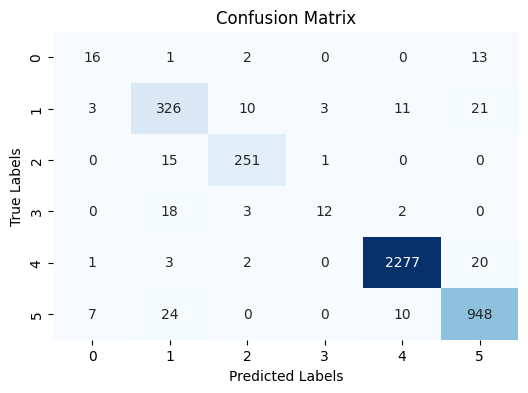

In [48]:
# Importing the LightGBM classifier
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier()
# Creating a pipeline with preprocessing and the LightGBM classifier
pipelgbm = make_pipeline(preprocessor, lgbm)
pipelgbm.fit(X_train, y_train)
y_pred = pipelgbm.predict(X_test)
lgbm_acc = accuracy_score(y_test, y_pred)
# Printing the accuracy of the LightGBM classifier
print(lgbm_acc)
# Printing the classification report for the predictions
print(classification_report(y_test, y_pred, digits=5))
# Calculating the weighted F1 score for the predictions
f1 = f1_score(y_test, y_pred, average='weighted')
# Printing the F1 score
print(f'F1 Score: {f1}')


accscore.append(lgbm_acc)
f1score.append(f1)
modelname.append('lgbm')

# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=True, yticklabels=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### HPT

In [49]:
''' 
#Define parameter grid for GridSearchCV
param_grid = {
    'lgbmclassifier__num_leaves': [31, 50, 70],
    'lgbmclassifier__max_depth': [-1, 10, 20, 30],
    'lgbmclassifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'lgbmclassifier__n_estimators': [100, 200, 300],
    'lgbmclassifier__min_child_samples': [20, 30, 40],
    'lgbmclassifier__subsample': [0.6, 0.8, 1.0],
    'lgbmclassifier__colsample_bytree': [0.6, 0.8, 1.0],
    'lgbmclassifier__reg_alpha': [0, 0.1, 0.5],
    'lgbmclassifier__reg_lambda': [0, 0.1, 0.5]
}

# Set up GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy score: ", grid_search.best_score_)

# Predict and evaluate the model on the test set
y_pred = grid_search.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Test set accuracy: {accuracy:.2f}')
'''

' \n#Define parameter grid for GridSearchCV\nparam_grid = {\n    \'lgbmclassifier__num_leaves\': [31, 50, 70],\n    \'lgbmclassifier__max_depth\': [-1, 10, 20, 30],\n    \'lgbmclassifier__learning_rate\': [0.01, 0.05, 0.1, 0.2],\n    \'lgbmclassifier__n_estimators\': [100, 200, 300],\n    \'lgbmclassifier__min_child_samples\': [20, 30, 40],\n    \'lgbmclassifier__subsample\': [0.6, 0.8, 1.0],\n    \'lgbmclassifier__colsample_bytree\': [0.6, 0.8, 1.0],\n    \'lgbmclassifier__reg_alpha\': [0, 0.1, 0.5],\n    \'lgbmclassifier__reg_lambda\': [0, 0.1, 0.5]\n}\n\n# Set up GridSearchCV\ngrid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=2, scoring=\'accuracy\')\n\n# Fit the model\ngrid_search.fit(X_train, y_train)\n\n# Best parameters and best score\nprint("Best parameters found: ", grid_search.best_params_)\nprint("Best accuracy score: ", grid_search.best_score_)\n\n# Predict and evaluate the model on the test set\ny_pred = grid_search.predict(X_test)\naccuracy = accur

## <u>Bagging Classifier</u>

Bagging Classifier accuracy: 0.94375
Accuracy: 0.94375
Classification Report:
                               precision    recall  f1-score   support

       Crimes against Persons       0.75      0.66      0.70        32
  Crimes against Public Order       0.82      0.87      0.85       374
Fraud and White-Collar Crimes       0.97      0.91      0.94       267
                 Other Crimes       0.50      0.31      0.39        35
              Property Crimes       0.99      0.99      0.99      2303
               Violent Crimes       0.95      0.96      0.95       989

                     accuracy                           0.96      4000
                    macro avg       0.83      0.78      0.80      4000
                 weighted avg       0.96      0.96      0.96      4000

F1 Score: 0.9572058224519923


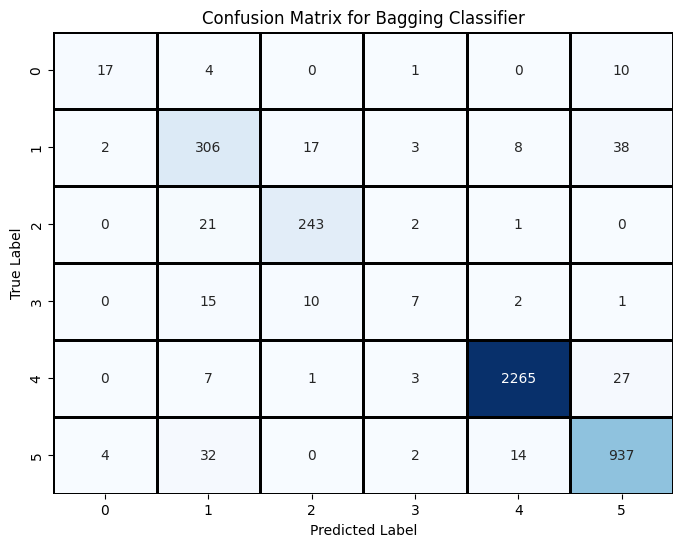

In [50]:
# Defining the base estimator as a Decision Tree classifier
base_estimator = DecisionTreeClassifier()
# Creating a Bagging classifier with 100 base estimators
bagging_classifier = BaggingClassifier(estimator=base_estimator, n_estimators=100, random_state=42)
# Creating a pipeline with preprocessing and the Bagging classifier
pipelinebg = make_pipeline(preprocessor, bagging_classifier)
# Training the pipeline on the training data
pipelinebg.fit(X_train, y_train)
# Predicting the target values for the test data
y_pred2 = pipelinebg.predict(X_test)
# Calculating the accuracy of the model
accuracy = accuracy_score(y_test, y_pred2)
# Printing the accuracy of the Bagging classifier
print(f'Bagging Classifier accuracy: {accuracy}')

f1 = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)
print(f'F1 Score: {f1}')

accscore.append(accuracy)
f1score.append(f1)
modelname.append('bg')


# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Bagging Classifier')
plt.show()

# <u>Step 7 - Validate and Implement</u>

In [51]:
print(accscore)
print(f1score)
print(modelname)

[0.57575, 0.95775, 0.91625, 0.9575, 0.9385, 0.93875, 0.9485, 0.94225, 0.958, 0.94375]
[0.4207368713311122, 0.4207368713311122, 0.9111781523224664, 0.9562706377987792, 0.9379414981421237, 0.9389304852011252, 0.9465378603934029, 0.9362773268855624, 0.9572058224519923, 0.9572058224519923]
['Dummy', 'xgb', 'KNN', 'SVM', 'DecisionTC', 'AdaBoost', 'MLP', 'RandomFClf', 'lgbm', 'bg']


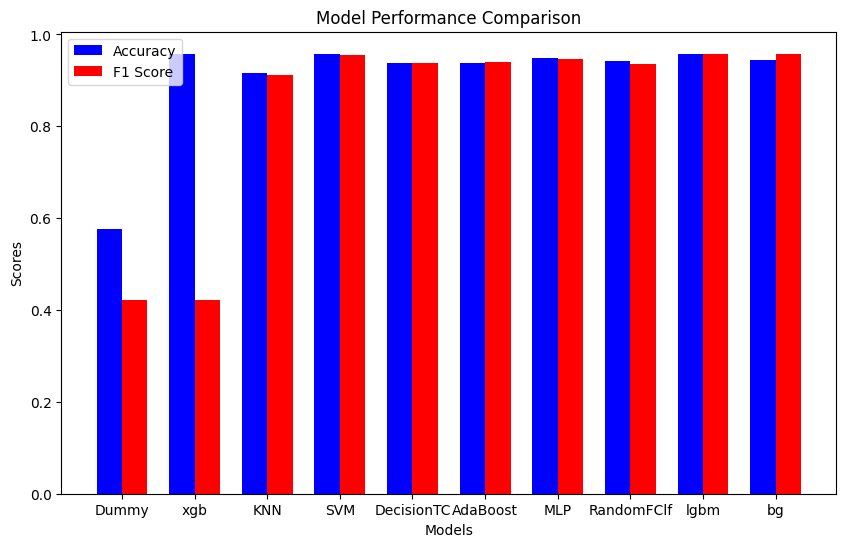

In [52]:
import matplotlib.pyplot as plt

# Setting the position of bars on the x-axis
bar_width = 0.35
index = np.arange(len(modelname))

# Plotting the accuracy and F1 score bars
plt.figure(figsize=(10, 6))
plt.bar(index, accscore, bar_width, label='Accuracy', color='b')
plt.bar(index + bar_width, f1score, bar_width, label='F1 Score', color='r')

# Adding labels and title
plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(index + bar_width / 2, modelname)
plt.legend()

# Displaying the plot
plt.show()


**To compare the performance of different machine learning models a bar plot has been created based on two metrics: Accuracy and F1 Score. It provides us a clear and intuitive comparison, making it easier to identify which models perform better overall. This visualization is valuable for highlighting the strengths and weaknesses of different models, helps in the selection of the best-performing model for the prediction.**

# <u>Step 8. Optimize and Submission</u>

## <u>VotingClassifier</u>

In [53]:
from sklearn.ensemble import VotingClassifier, StackingClassifier


In [54]:
voting_clf = VotingClassifier(
    estimators=[
        ('svm' ,pipelinesvm), # List of tuples containing the name and pipeline for each classifier
        ('lgbm', pipelgbm),
        ('mlp', pipelinemlp)
    ]
)

In [55]:
voting_clf # The VotingClassifier will combine the predictions of the above classifiers

VotingClassifier(estimators=[('svm',
                              Pipeline(steps=[('columntransformer',
                                               ColumnTransformer(transformers=[('num',
                                                                                StandardScaler(),
                                                                                ['Latitude',
                                                                                 'Longitude',
                                                                                 'Time_Occurred',
                                                                                 'Area_ID',
                                                                                 'Reporting_District_no',
                                                                                 'Part '
                                                                                 '1-2',
                                                                                 'Victim_Age',
                                                                                 'Premise_Code',
                                                                                 'Weapon_Used_Code']),
                                                                               ('Location',
                                                                                TfidfVectorizer(max_features=6000,
                                                                                                stop_words='english'),
                                                                                'Location'),
                                                                               ('Clau...
                                                                                 'Premise_Code',
                                                                                 'Weapon_Used_Code']),
                                                                               ('Location',
                                                                                TfidfVectorizer(max_features=6000,
                                                                                                stop_words='english'),
                                                                                'Location'),
                                                                               ('Clause_no',
                                                                                CountVectorizer(),
                                                                                'Modus_Operandi'),
                                                                               ('Weapon_Description',
                                                                                TfidfVectorizer(max_features=6000,
                                                                                                stop_words='english'),
                                                                                'Weapon_Description')])),
                                              ('mlpclassifier',
                                               MLPClassifier(early_stopping=True,
                                                             max_iter=1000,
                                                             random_state=42))]))])

In [56]:
voting_clf.voting = "soft"
voting_clf.named_estimators["svm"].probability = True
voting_clf.fit(X_train, y_train)
# Predicting the target values for the test data
y_pred4 = voting_clf.predict(X_test)
# Calculating the accuracy of the model
accuracy = accuracy_score(y_test, y_pred4)
# Printing the accuracy of the Bagging classifier
print(f'Voting Classifier accuracy: {accuracy}')

/opt/conda/lib/python3.10/site-packages/sklearn/svm/_base.py:299: ConvergenceWarning:

Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8642
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 577
[LightGBM] [Info] Start training from score -4.417654
[LightGBM] [Info] Start training from score -2.412121
[LightGBM] [Info] Start training from score -2.688248
[LightGBM] [Info] Start training from score -4.710531
[LightGBM] [Info] Start training from score -0.535823
[LightGBM] [Info] Start training from score -1.443394
Voting Classifier accuracy: 0.9565


In [57]:
#calculating the f1 score
f1 = f1_score(y_test, y_pred4, average='weighted')
report = classification_report(y_test, y_pred4)
#printing the reports
print('Classification Report:')
print(report)
print(f'F1 Score: {f1}')

Classification Report:
                               precision    recall  f1-score   support

       Crimes against Persons       0.71      0.53      0.61        32
  Crimes against Public Order       0.82      0.86      0.84       374
Fraud and White-Collar Crimes       0.96      0.92      0.94       267
                 Other Crimes       0.53      0.23      0.32        35
              Property Crimes       0.99      0.99      0.99      2303
               Violent Crimes       0.95      0.96      0.95       989

                     accuracy                           0.96      4000
                    macro avg       0.83      0.75      0.78      4000
                 weighted avg       0.95      0.96      0.95      4000

F1 Score: 0.9547769134970685


**We have applied VotingClassifier that combines the predictions from three different models namely Support Vector Machine (SVM), LightGBM, and Multi-Layer Perceptron (MLP). Each of these models is represented by a pipeline that include preprocessing steps. The classifier will then make predictions based on a combination of the outputs of these individual models.**

## <u>Stacking Classifier</u>

In [58]:
from sklearn.ensemble import StackingClassifier

stacking_clf = StackingClassifier(  
    estimators = [
        ('svm' ,pipelinesvm),
        ('lgbm', pipelgbm),
        ('mlp', pipelinemlp)
    ],
    final_estimator = RandomForestClassifier(random_state= 42), #The final_estimator is a RandomForestClassifier
    cv=5 #5-fold cross-validation will be used to train
)

In [59]:
stacking_clf

StackingClassifier(cv=5,
                   estimators=[('svm',
                                Pipeline(steps=[('columntransformer',
                                                 ColumnTransformer(transformers=[('num',
                                                                                  StandardScaler(),
                                                                                  ['Latitude',
                                                                                   'Longitude',
                                                                                   'Time_Occurred',
                                                                                   'Area_ID',
                                                                                   'Reporting_District_no',
                                                                                   'Part '
                                                                                   '1-2',
                                                                                   'Victim_Age',
                                                                                   'Premise_Code',
                                                                                   'Weapon_Used_Code']),
                                                                                 ('Location',
                                                                                  TfidfVectorizer(max_features=6000,
                                                                                                  stop_words='english'),
                                                                                  'Location')...
                                                                                  TfidfVectorizer(max_features=6000,
                                                                                                  stop_words='english'),
                                                                                  'Location'),
                                                                                 ('Clause_no',
                                                                                  CountVectorizer(),
                                                                                  'Modus_Operandi'),
                                                                                 ('Weapon_Description',
                                                                                  TfidfVectorizer(max_features=6000,
                                                                                                  stop_words='english'),
                                                                                  'Weapon_Description')])),
                                                ('mlpclassifier',
                                                 MLPClassifier(early_stopping=True,
                                                               max_iter=1000,
                                                               random_state=42))]))],
                   final_estimator=RandomForestClassifier(random_state=42))

In [60]:
import warnings
from sklearn.exceptions import ConvergenceWarning
# Suppress the ConvergenceWarning
warnings.filterwarnings("ignore", message="Solver terminated early ",  category=ConvergenceWarning)
stacking_clf.fit(X_train, y_train)
# Predicting the target values for the test data
y_pred5 = stacking_clf.predict(X_test)

# Calculating the accuracy of the model
accuracy = accuracy_score(y_test, y_pred5)
# Printing the accuracy of the Bagging classifier
print(f'Stacking Classifier accuracy: {accuracy}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057611 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8642
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 577
[LightGBM] [Info] Start training from score -4.417654
[LightGBM] [Info] Start training from score -2.412121
[LightGBM] [Info] Start training from score -2.688248
[LightGBM] [Info] Start training from score -4.710531
[LightGBM] [Info] Start training from score -0.535823
[LightGBM] [Info] Start training from score -1.443394
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040823 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7300
[LightGBM] [Info] Number of data points in the train set: 1280

In [61]:
f1 = f1_score(y_test, y_pred5, average='weighted')
report = classification_report(y_test, y_pred5)


print('Classification Report:')
print(report)
print(f'F1 Score: {f1}')

Classification Report:
                               precision    recall  f1-score   support

       Crimes against Persons       0.70      0.59      0.64        32
  Crimes against Public Order       0.81      0.89      0.85       374
Fraud and White-Collar Crimes       0.96      0.91      0.93       267
                 Other Crimes       0.58      0.20      0.30        35
              Property Crimes       0.99      0.99      0.99      2303
               Violent Crimes       0.95      0.96      0.95       989

                     accuracy                           0.96      4000
                    macro avg       0.83      0.76      0.78      4000
                 weighted avg       0.96      0.96      0.96      4000

F1 Score: 0.9555791526515776


**The StackingClassifier combines predictions from multiple base classifiers (SVM, LightGBM, MLP).<br>
 The code fits a StackingClassifier to the training data, makes predictions on the test data, and calculates the accuracy of these predictions.**

## <u>Submission file creation</u>

In [62]:
test['Cross_Street'] = test['Cross_Street'].fillna('')
test['Modus_Operandi'] = test['Modus_Operandi'].fillna('')
test['Victim_Sex'] = test['Victim_Sex'].fillna('')
test['Victim_Descent'] = test['Victim_Descent'].fillna('')
test['Weapon_Used_Code'] = test['Weapon_Used_Code'].fillna(0)
test['Weapon_Description'] = test['Weapon_Description'].fillna('')

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import pandas as pd

# Defining the specific columns for imputation
string_columns = ['Cross_Street', 'Modus_Operandi', 'Victim_Sex', 'Victim_Descent', 'Weapon_Description']
numeric_columns = ['Weapon_Used_Code']

# Creating a pipeline for imputing string columns
string_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=''))
])

# Creating a pipeline for imputing numeric columns
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])

# Combining the pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('str', string_pipeline, string_columns),
        ('num', numeric_pipeline, numeric_columns)
    ],
    remainder='passthrough'  # To keep the other columns as they are
)

# Applying the ColumnTransformer to the DataFrame
test_imputed = preprocessor.fit_transform(test)

# Convert the result back to a DataFrame with the original column names
# Assuming test.columns gives the original column order
test_imputed = pd.DataFrame(test_imputed, columns=test.columns)

In [64]:
y_pred= pipelgbm.predict(test)
submission=pd.DataFrame({"ID":range(1,5001),'Crime_Category':y_pred})
submission.to_csv('submission.csv',index=False)